# Intro to Python Plotting

Python is one of the top coding languages for analyzing and plotting scientific data, both in the HPC world and in general. This notebook contains a set of examples to get you started with common Python packages used for basic plotting. Specifically, we'll cover an introduction to Matplotlib, the fundamental plotting library for Python, as well as how it pairs with the NumPy and Pandas packages.

Packages in this notebook:

* [Matplotlib](https://matplotlib.org/stable/users/index.html): The most common general-purpose plotting library. Specifically we will be using the "pyplot" subpackage of Matplotlib for its useful plotting functions. "Matplotlib" and "pyplot" will be used interchangeably in this notebook
* [NumPy](https://numpy.org/doc/stable/): Used for processing data. Uses general n-dimensional "arrays" but does not have native plotting functions like Pandas. For that reason, it is usually paired with matplotlib
* [Pandas](https://pandas.pydata.org/docs/user_guide/index.html#user-guide): Used for processing and plotting data. Uses "dataframes" that are specialized to handle **tabulated** data. Also has native plotting capabilities
* [[Optional] Seaborn](https://seaborn.pydata.org/): Typically used for generating statistical graphs and uses matplotlib behind the scenes

### What is Matplotlib?
- Matplotlib is a comprehensive library for creating static, and interactive visualizations in Python
- It provides a MATLAB-like interface for plotting
- Essential for data visualization, data analysis, and scientific computing
- Works seamlessly with NumPy and Pandas

### **Table of Contents**

* [**Matplotlib Basics**](#packages)
    * [Getting Started with Numpy](#getting-started)
    * [1. Figure and Axes](#figs-and-axes)
    * [2. Customizing Plots: Colors, Styles, Markers, and Labels](#customize)
    * [3. Scatter Plots](#scatter)
    * [4. Bar Charts](#bars)
    * [5. Histograms and Pie Charts](#hists-and-pies)
    * [6. Pandas Dataframes](#pandas)
    * [7. Subplots](#subplots)
    * [8. Advanced Plots](#advanced-plots)
    * [9. Advanced Customization](#advanced-custom)
    * [10. Saving Figures](#save)
* [Cheat Sheet](#cheat-sheet)
* [Extra Content](#optional)
    * [Seaborn](#seaborn)
    * [More Cool Plots](#cool-plots)
* [Additional Packages To Explore](#more-packages)

### <a name="packages"></a> Import Packages

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# For Jupyter notebooks, use this magic command to display plots inline
%matplotlib inline

# Optional: Set style for better-looking plots
plt.style.use('default')  # You can also use 'seaborn', 'ggplot', etc.

> **Note:** How you use `import package_name as package_shorthand` comes down to personal preference. For your future work, feel free to use whichever `package_shorthand` you prefer.

### <a name="getting-started"></a> Getting Started with NumPy

NumPy is most known for its implementation of arrays, but you can also use built-in mathematical operations (e.g., trig functions).

In [231]:
# Generate some data using NumPy arrays
x1 = np.array((1,2,3,4,5)) # x-axis values
y1 = np.array((6,7,8,9,10)) # y-axis values
print(x1,y1)

# Generate a dataset by mapping x-values to a sine curve
x2 = np.linspace(0, 10, 100)  # 100 equally-spaced points from 0 to 10
y2 = np.sin(x2)
print(x2,y2)

[1 2 3 4 5] [ 6  7  8  9 10]
[ 0.          0.1010101   0.2020202   0.3030303   0.4040404   0.50505051
  0.60606061  0.70707071  0.80808081  0.90909091  1.01010101  1.11111111
  1.21212121  1.31313131  1.41414141  1.51515152  1.61616162  1.71717172
  1.81818182  1.91919192  2.02020202  2.12121212  2.22222222  2.32323232
  2.42424242  2.52525253  2.62626263  2.72727273  2.82828283  2.92929293
  3.03030303  3.13131313  3.23232323  3.33333333  3.43434343  3.53535354
  3.63636364  3.73737374  3.83838384  3.93939394  4.04040404  4.14141414
  4.24242424  4.34343434  4.44444444  4.54545455  4.64646465  4.74747475
  4.84848485  4.94949495  5.05050505  5.15151515  5.25252525  5.35353535
  5.45454545  5.55555556  5.65656566  5.75757576  5.85858586  5.95959596
  6.06060606  6.16161616  6.26262626  6.36363636  6.46464646  6.56565657
  6.66666667  6.76767677  6.86868687  6.96969697  7.07070707  7.17171717
  7.27272727  7.37373737  7.47474747  7.57575758  7.67676768  7.77777778
  7.87878788  7.979797

You can also generate your own random data using numpy.

This will come into play later.

In [236]:
x3 = np.linspace(0,1000,1000) # start, stop, num
y3 = np.random.rand(1000) # num, from interval [0,1) by default
print(x3,y3)

[   0.            1.001001      2.002002      3.003003      4.004004
    5.00500501    6.00600601    7.00700701    8.00800801    9.00900901
   10.01001001   11.01101101   12.01201201   13.01301301   14.01401401
   15.01501502   16.01601602   17.01701702   18.01801802   19.01901902
   20.02002002   21.02102102   22.02202202   23.02302302   24.02402402
   25.02502503   26.02602603   27.02702703   28.02802803   29.02902903
   30.03003003   31.03103103   32.03203203   33.03303303   34.03403403
   35.03503504   36.03603604   37.03703704   38.03803804   39.03903904
   40.04004004   41.04104104   42.04204204   43.04304304   44.04404404
   45.04504505   46.04604605   47.04704705   48.04804805   49.04904905
   50.05005005   51.05105105   52.05205205   53.05305305   54.05405405
   55.05505506   56.05605606   57.05705706   58.05805806   59.05905906
   60.06006006   61.06106106   62.06206206   63.06306306   64.06406406
   65.06506507   66.06606607   67.06706707   68.06806807   69.06906907
   70.07

## <a name="figs-and-axes"></a> Section 1: Figures and Axes

**Key Concepts:**
- **Figure**: The top-level container (the entire window/page)
- **Axes**: The actual plot area (where data is drawn)
- **Axis**: A single number line (x-axis, y-axis)
- Think of the figure as a canvas, and axes as individual paintings on that canvas

**Commands:**
- Plot - Creates a relationship/function between two sets of data
- Title - Title label
- Legend - Legend for any plot labels; **Must be enabled to show labels**
- Show - Necessary to display outside of notebooks

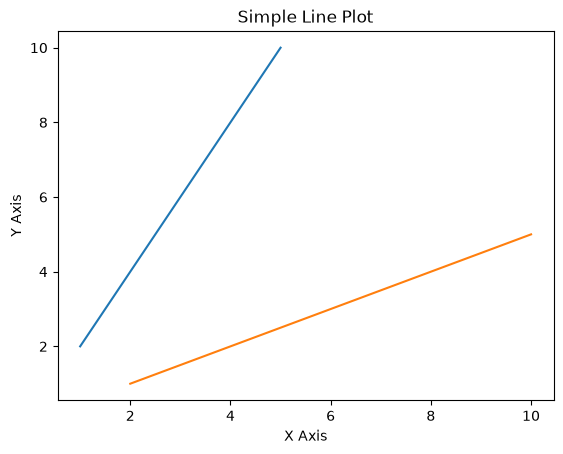

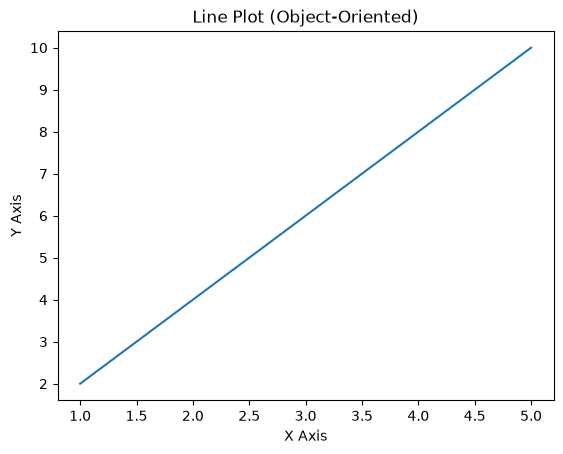

In [27]:
x = [1, 2, 3, 4, 5]
y = [2, 4, 6, 8, 10]

# Method 1: Pyplot approach (quick and simple)
plt.plot(x, y)
plt.plot(y, x)
plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Simple Line Plot')
plt.show()


# Method 2: Object-oriented approach (more control, recommended for complex plots)
fig, ax = plt.subplots()  # Creates a figure and axes object. Notice that this uses the axes API rather than the default
ax.plot(x, y)
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_title('Line Plot (Object-Oriented)')
plt.show()

## <a name="customize"></a> Section 2: Customizing Plots: Colors, Styles, Markers, and Labels

Various aesthetic options are available; I listed some popular ones below.

**Styling Options**
- Markers
    - d = diamond
    - o = circle
    - ^ = triangle
- Line Styling (ls)
    - '--' = dashed
    - '-' = solid
    - ':' = dotted
    - '' = empty
- Colors
    - k = black
    - r = red
    - g = green
    - b = blue (default)
    - c = cyan
    - m = magenta
    - y = yellow
- Labels (Add any text)


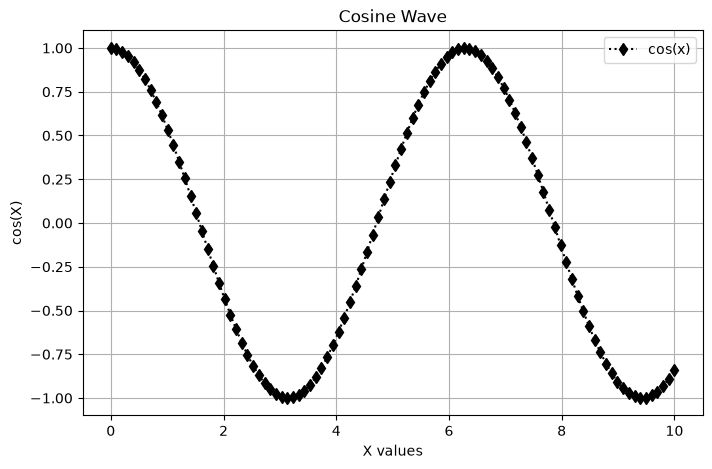

In [246]:
# Create some sample data
x = np.linspace(0, 10, 100)  # 100 points from 0 to 10
y = np.cos(x)

# Simple line plot
plt.figure(figsize=(8, 5))  # figsize=(width, height) in inches
plt.plot(x, y, label="cos(x)", marker = 'd', ls = ':', color = '#000000')
plt.xlabel('X values')
plt.ylabel('cos(X)')
plt.title('Cosine Wave')
plt.legend()
plt.grid(True)  # Add grid for easier reading
plt.show()

Say you had a large set of data and need to set limits on your axes.

Limits allow you to do just that.

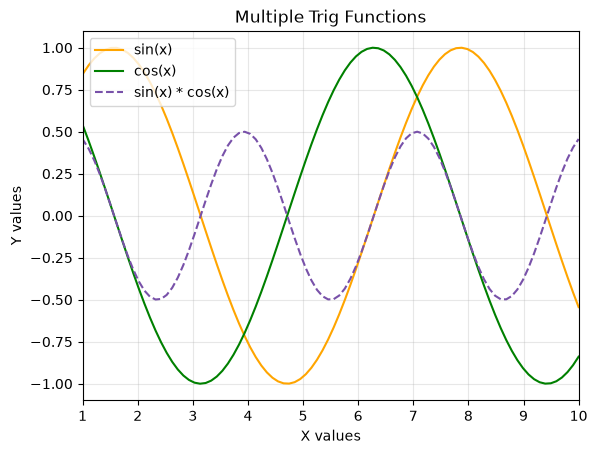

In [ ]:
# Multiple lines on the same plot

# Three different trig graphs
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.cos(x)

# Using subplot to show detailed control over axes
fig, ax = plt.subplots()
ax.plot(x, y1, label='sin(x)', color="orange")
ax.plot(x, y2, label='cos(x)', color='g')
ax.plot(x, y3, label='sin(x) * cos(x)', color='#7851A9', ls='--')

# Axis Labels and Limits
ax.set_xlabel('X values')
ax.set_ylabel('Y values')
#ax.set_xscale('log')    # Change this value to see what happens
ax.set_xlim(1,10)        # Change this value and see what happens

ax.set_title('Multiple Trig Functions')
ax.legend()  # Show legend
ax.grid(True, alpha=0.3)  # alpha controls transparency
plt.show()

### More Customization

Matplotlib offers extensive customization options to make your plots visually appealing and informative.

When you assign a color, you can do so in several different ways:
- Color abbreviation (e.g., color='k' for black)
- Explicit color name (e.g., color='black')
- Hex Code (e.g., color='#000000')

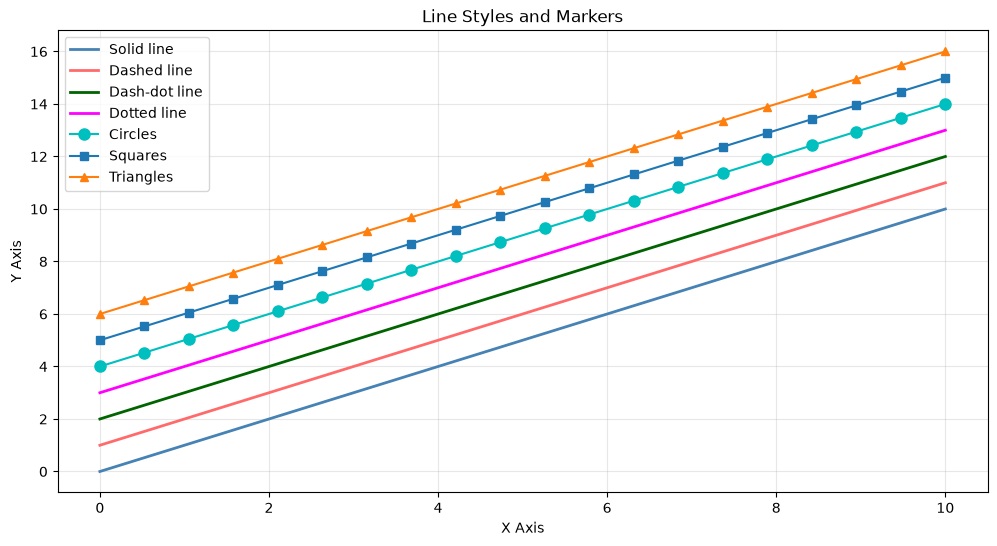

In [44]:
x = np.linspace(0, 10, 20)

# Different line styles and markers
# Using a mix of color abbreviations, explicit color names, and hex codes
plt.figure(figsize=(12, 6))

plt.plot(x, x, color='steelblue', label='Solid line', linewidth=2)
plt.plot(x, x+1, color='#FF6B6B', label='Dashed line', linewidth=2)
plt.plot(x, x+2, color='darkgreen', label='Dash-dot line', linewidth=2)
plt.plot(x, x+3, color='magenta', label='Dotted line', linewidth=2)
plt.plot(x, x+4, 'co-', label='Circles', markersize=8)
plt.plot(x, x+5, 's-', label='Squares', markersize=6)
plt.plot(x, x+6, '^-', label='Triangles', markersize=6)

plt.xlabel('X Axis')
plt.ylabel('Y Axis')
plt.title('Line Styles and Markers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## <a name="scatter"></a> Section 3: Scatter Plots

Scatter plots are excellent for visualizing relationships between two variables and identifying correlations. Matplotlib lets you take one step further with scatter plots.

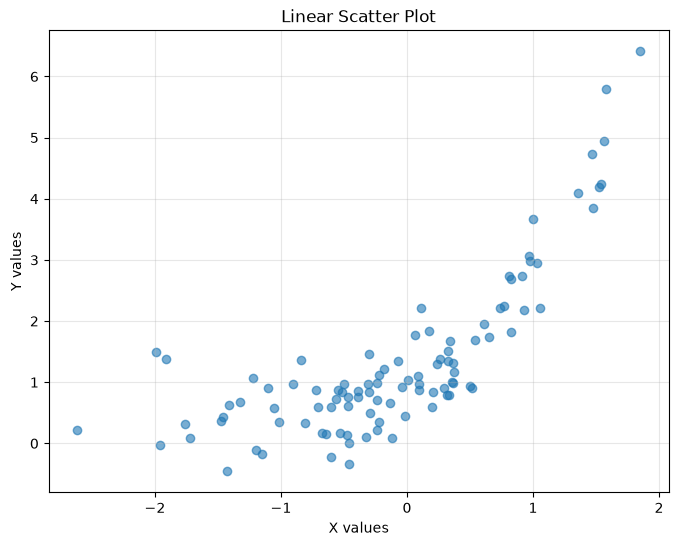

In [ ]:
# Generate sample data with a linear relationship
np.random.seed(42)
x = np.random.randn(100)
y = x + np.random.randn(100) * 0.5  # Linear relationship with noise

# TODO: Change y to a nonlinear function and reduce noise to 0.25.


# Basic scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6)  # alpha controls transparency
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Linear Scatter Plot')
plt.grid(True, alpha=0.3)
plt.show()

Let's look at examples where we can adjust the color and size of the data points. In this first example, we'll randomize the color and size for each point. You can set a color mapping using the 'cmap' parameter.

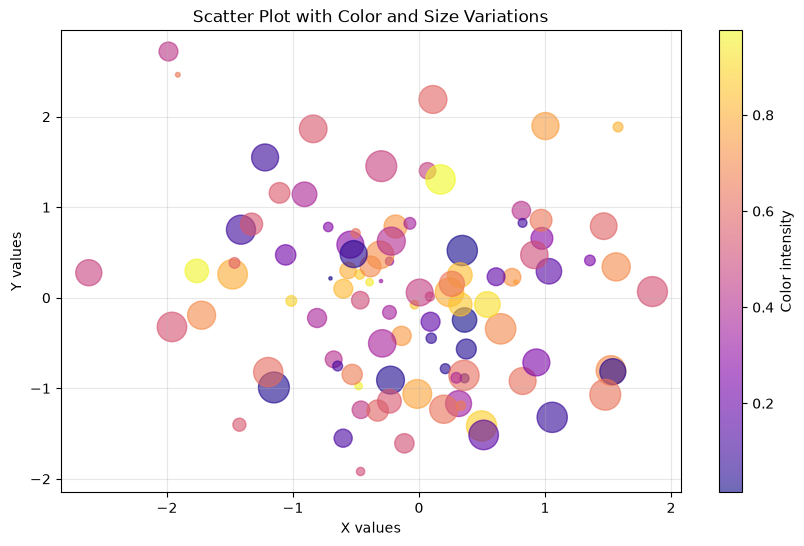

In [252]:
# Random Overlapping Scatter plot with different colors and sizes
np.random.seed(42)
x = np.random.randn(100)
y = np.random.randn(100)
colors = np.random.rand(100)  # Random colors
sizes = 500 * np.random.rand(100)  # Random sizes


plt.figure(figsize=(10, 6))
plt.scatter(x, y, c=colors, s=sizes, alpha=0.6, cmap='plasma')
plt.colorbar(label='Color intensity')  # Add colorbar
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Scatter Plot with Color and Size Variations')
plt.grid(True, alpha=0.3)
plt.show()

# Popular colormaps: 'viridis', 'plasma', 'coolwarm', 'RdYlBu', 'Set1'


In this second example, we want size to be meaningful, so let's make it dependent on the x-position. This gives us a clearer idea of perhaps more subtle patterns in the data.

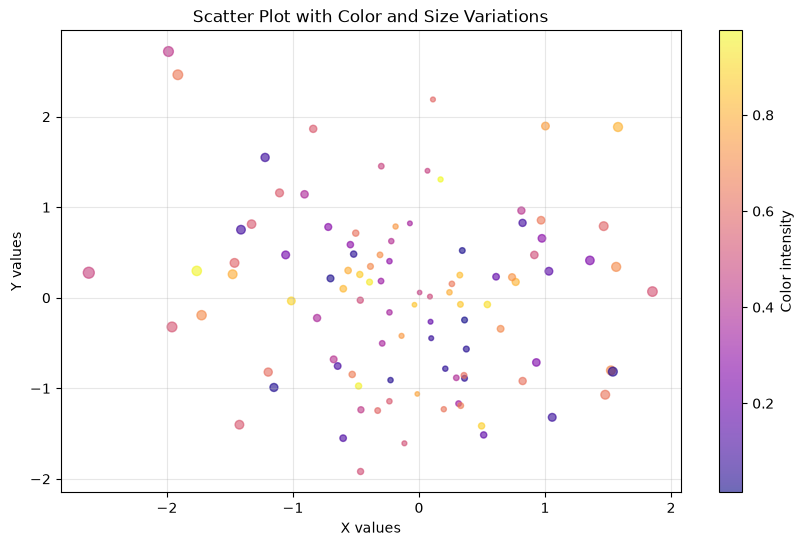

In [ ]:
# Scatter plot where size depends on x-value
np.random.seed(42)
x = np.random.randn(100)
y = np.random.randn(100)
colors = np.random.rand(100)  # Random colors

min_size = 10
max_size = 100
# Normalize X between 0 and 1, then scale to our desired range
x_normalized = (abs(x)) / (x.max() - x.min())
sizes = min_size + x_normalized * (max_size - min_size)


plt.figure(figsize=(10, 6))
plt.scatter(x, y, c=colors, s=sizes, alpha=0.6, cmap='plasma')
plt.colorbar(label='Color intensity')  # Add colorbar
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Scatter Plot with Color and Size Variations')
plt.grid(True, alpha=0.3)
plt.show()

## <a name="bars"></a> Section 4: Bar Charts
Bar charts are ideal for comparing groups, or categorical data. They allow you to compare counts between multiple groups.

We can generate values for an example dataset using the built-in random package. Let's make an example dataset that randomly generates the counts of different quantum gates.

The implementation for vertical and horizontal bar charts are slightly different.

Vertical (Default): `plt.bar(categories, values, ...)`

vs.

Horizontal: `plt.barh(categories, values, ...)`

[1, 11, 7, 8, 9]


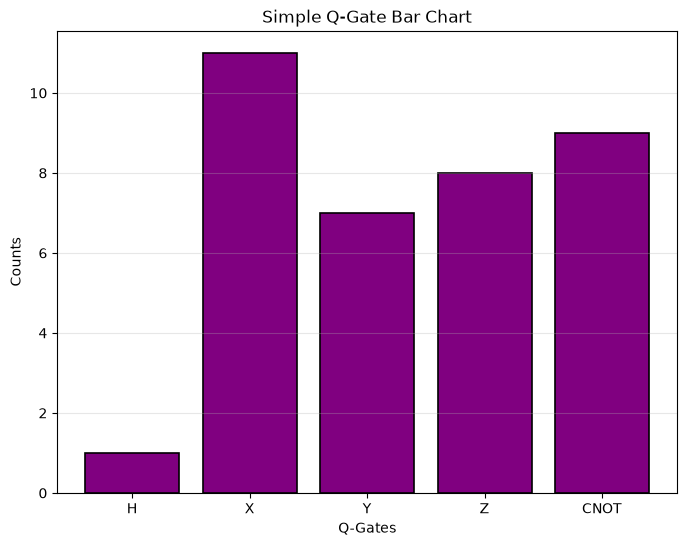

In [13]:
# Simple bar chart
import random
categories = ['H', 'X', 'Y', 'Z', 'CNOT']
values = [random.randint(1,12) for i in range(5)]
print(values)

plt.figure(figsize=(8, 6))
plt.bar(categories, values, color='purple', edgecolor='black', linewidth=1.2)
plt.xlabel('Q-Gates')
plt.ylabel('Counts')
plt.title('Simple Q-Gate Bar Chart')
plt.grid(True, alpha=0.3, axis='y')  # Only horizontal grid lines
plt.show()

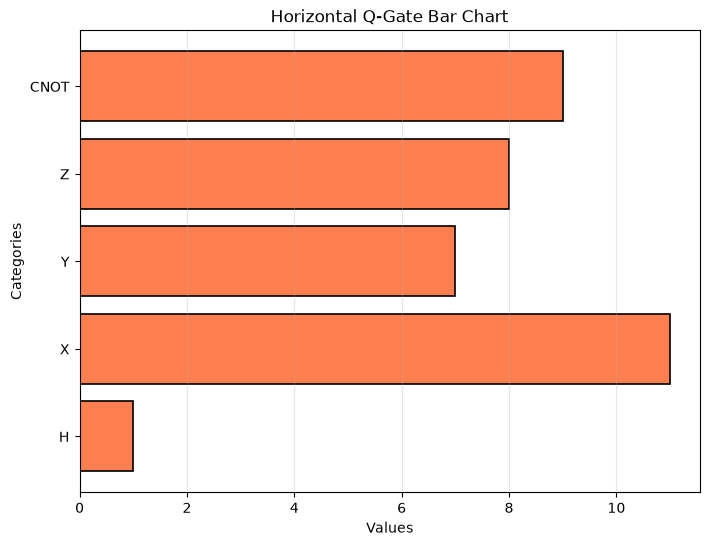

In [14]:
# Horizontal bar chart
plt.figure(figsize=(8, 6))
plt.barh(categories, values, color='coral', edgecolor='black', linewidth=1.2)
plt.xlabel('Values')
plt.ylabel('Categories')
plt.title('Horizontal Q-Gate Bar Chart')
plt.grid(True, alpha=0.3, axis='x')
plt.show()

Bar charts are also useful for visualizing groups of categorical data over different periods or regions.

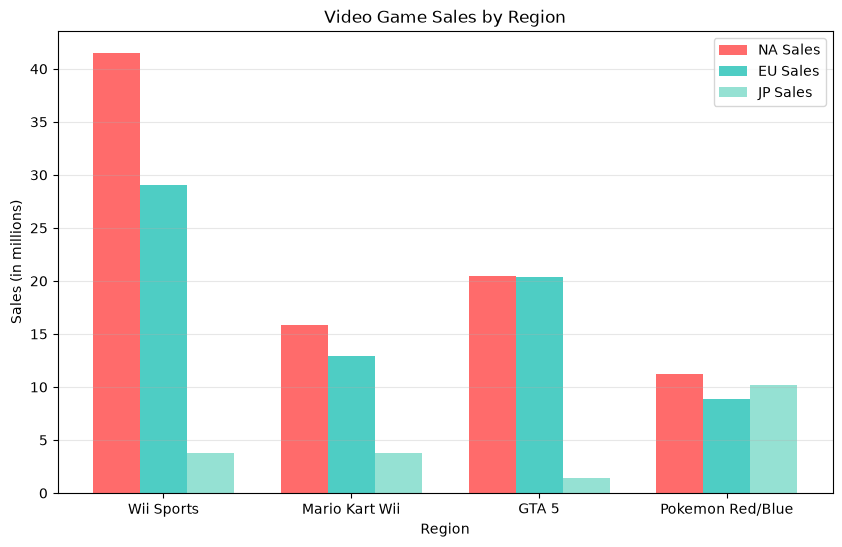

In [53]:
# Grouped bar chart
categories = ['Wii Sports', 'Mario Kart Wii', 'GTA 5', 'Pokemon Red/Blue']
NA_sales = [41.49, 15.85, 20.44, 11.27]
EU_sales = [29.02, 12.88, 20.39, 8.89]
JP_sales = [3.77, 3.79, 1.39, 10.22]

x = np.arange(len(categories))
width = 0.25  # Width of bars

plt.figure(figsize=(10, 6))
plt.bar(x - width, NA_sales, width, label='NA Sales', color='#FF6B6B')    # x: center position for second group (no shift)
plt.bar(x, EU_sales, width, label='EU Sales', color='#4ECDC4')            # x + width: x-position (shift right by one bar width to position third group)
plt.bar(x + width, JP_sales, width, label='JP Sales', color='#95E1D3')

plt.xlabel('Region')
plt.ylabel('Sales (in millions)')
plt.title('Video Game Sales by Region')
plt.xticks(x, categories)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## <a name="hists-and-pies"></a> Section 5: Histograms & Pie Charts

### Histograms
Histograms can be used to distribute numerical data over a set of bins.

* Here we define a random normal data distribution of size `N_points`.
* In the first example, we see `data = np.random.normal(70, 10, 1000)`. This means the histogram is centered around 70, has a standard deviation of 10, and 1000 data .

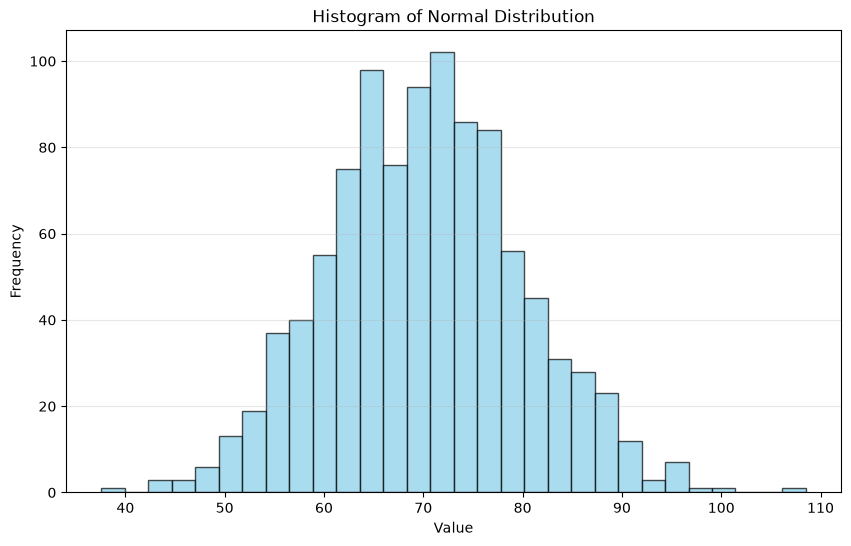

In [ ]:
# Generate sample data
np.random.seed(42)
data = np.random.normal(70, 10, 1000)  # Mean = 70, Std Dev = 10, 1000 points

# Basic histogram
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Normal Distribution')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

Overlapping histograms are simply distributions that act independently of one another and overlap based on their means and deviations.

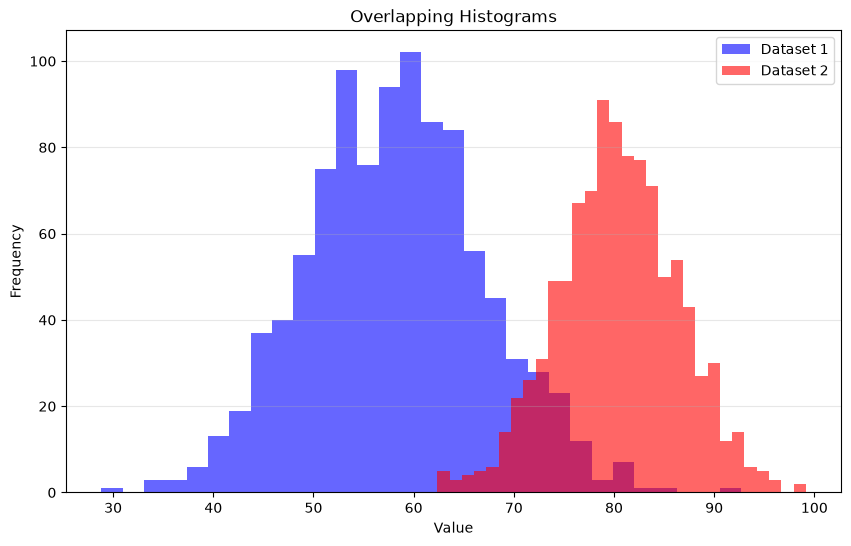

In [ ]:
# Multiple histograms on the same plot
np.random.seed(42)
data1 = np.random.normal(58, 9, 1000)
data2 = np.random.normal(80, 6, 1000)

plt.figure(figsize=(10, 6))
plt.hist(data1, bins=30, alpha=0.6, label='Dataset 1', color='blue')
plt.hist(data2, bins=30, alpha=0.6, label='Dataset 2', color='red')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Overlapping Histograms')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.show()

### Pie Charts
Pie charts are useful for showing proportions and percentages.

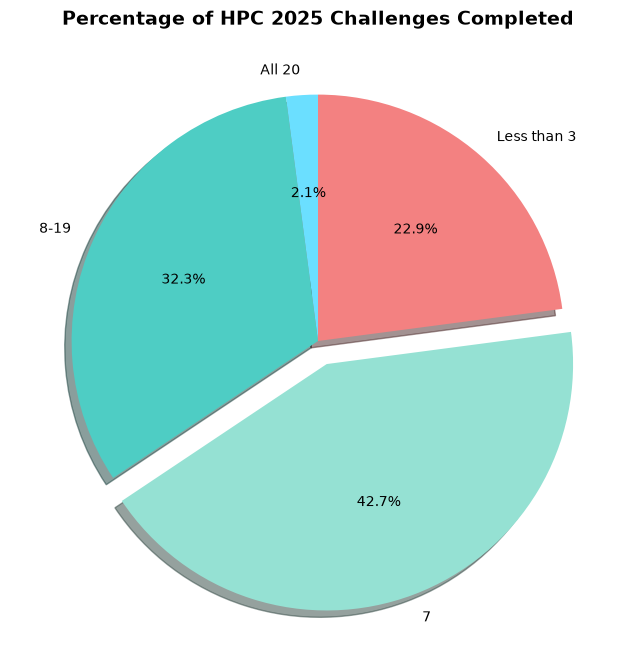

In [255]:
# Simple pie chart
categories = ['All 20', '8-19', '7', 'Less than 3']
sizes = [2, 31, 41, 22]
colors = ["#6BDFFFFF", '#4ECDC4', '#95E1D3', '#F38181']
explode = (0, 0, 0.1, 0)  # Explode the slice for 'exactly 7'

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, explode=explode, labels=categories, colors=colors,
       autopct='%1.1f%%', shadow=True, startangle=90)
ax.set_title('Percentage of HPC 2025 Challenges Completed', fontsize=14, fontweight='bold')
plt.show()

**Note:** The above pie chart is based on real data from the 2025 HPC Crash Course

## <a name="pandas"></a> Section 6: Pandas Dataframes

In [54]:
import pandas as pd

Pandas offers DataFrames to efficiently store data and glean data from spreadsheets. A Pandas DataFrame can be plotted directly via the `plot()` method. You provide the rows (as arrays) and then the column labels.

By default, Pandas will plot data against the index value of each row (for every named column). If you're using the Axes API, you can pass `ax` arguments via `df.plot(ax=name_of_axes)`. In our case, the name of our axis is `ax`, so we use `df.plot(ax=ax)`.

Below we compare how plots appear when using Pandas vs. the native plotting feature of Matplotlib. Notice that Pandas automatically includes a legend, while Matplotlib provides the option to exclude a legend or customize it.

We also should talk about cleaning our data. Your data isn't always going to be perfect. You're going to have noise and missing values at some point. When that happens you can either drop the missing rows with `nf.dropna()` or replace the missing value with `nf.replace(np.nan, new_value)`.

NumPy DataFrame:
     a    b    c
0  NaN  2.0  3.0
1  4.0  5.0  6.0
2  7.0  8.0  9.0
     a    b    c
0  1.0  2.0  3.0
1  4.0  5.0  6.0
2  7.0  8.0  9.0


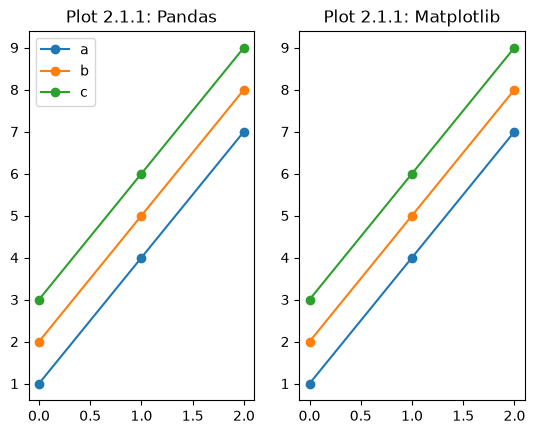

In [ ]:
# Create a Pandas DataFrame
df = pd.DataFrame( np.array( ([np.nan,2,3] , [4,5,6] , [7,8,9]) ), columns=['a','b','c'] )
print("NumPy DataFrame:")
print(df)

# This is how you can handle missing data
# Two Options for handling missing values

# Method #1: Drop the missing values
df = df.dropna()

# Method #2: Fill the missing values (just reversing the logic of inserting the missing values)
#df = df.replace(np.nan, 1)
print(df)


fig, ax = plt.subplots(nrows=1,ncols=2)

# Plot via Pandas
df.plot(marker='o',ax=ax[0])

# Plot via Matplotlib
ax[1].plot(df,marker='o')

ax[0].set_title('Plot 2.1.1: Pandas')
ax[1].set_title('Plot 2.1.1: Matplotlib')

plt.show()

Here's another sample dataframe. Use it to generate a plot.

There are more filtering/query-like prompts that possible with Pandas. We are only going to focus on a condensed overview focused on the plotting features.

**Commands:**
- `df.head()`: Shows the first 5 rows
- `df.tail()`: Shows the last 5 rows
- `df[[<colName1>, <colName2>, ...]]`: Shows all rows of the DataFrame with the specified column names
- `df.info()`: Gives a summary of the dataset


In [262]:
# Create a sample DataFrame
np.random.seed(42)
dates = pd.date_range('2023-01-01', periods=100, freq='D')
df = pd.DataFrame({
    'Date': dates,
    'Sales': np.random.randint(1000, 5000, 100) + np.sin(np.arange(100)) * 500,
    'Profit': np.random.randint(200, 800, 100) + np.cos(np.arange(100)) * 200,
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 100)
})

print("Sample DataFrame:\n\n")
print("Head (First 5 lines):")
print(df.head())                    # Prints the first 5 lines
print()

print("Tail (Last 5 lines):")        # Prints the last 5 lines
print(df.tail())
print()

print("Table with only dates and sales:")
print(df[["Date", "Sales"]])        # Finding a subtable based on the "Date" and "Sales" columns
print()

df.info()
print()

print(f"\nDataFrame shape: {df.shape}")

Sample DataFrame:


Head (First 5 lines):
        Date        Sales      Profit Region
0 2023-01-01  4174.000000  801.000000  South
1 2023-01-02  4927.735492  863.060461   East
2 2023-01-03  2314.648713  277.770633  South
3 2023-01-04  2364.560004  203.001501   East
4 2023-01-05  1751.598752  338.271276  North

Tail (Last 5 lines):
         Date        Sales      Profit Region
95 2023-04-06  2470.630857  458.034712  North
96 2023-04-07  5334.793873  659.913910  South
97 2023-04-08  5082.803870  455.970493  North
98 2023-04-09  2213.309064  599.142351   West
99 2023-04-10  1202.396583  474.964176  South

Table with only dates and sales:
         Date        Sales
0  2023-01-01  4174.000000
1  2023-01-02  4927.735492
2  2023-01-03  2314.648713
3  2023-01-04  2364.560004
4  2023-01-05  1751.598752
..        ...          ...
95 2023-04-06  2470.630857
96 2023-04-07  5334.793873
97 2023-04-08  5082.803870
98 2023-04-09  2213.309064
99 2023-04-10  1202.396583

[100 rows x 2 columns]

<class 

Now, let's plot our DataFrame.

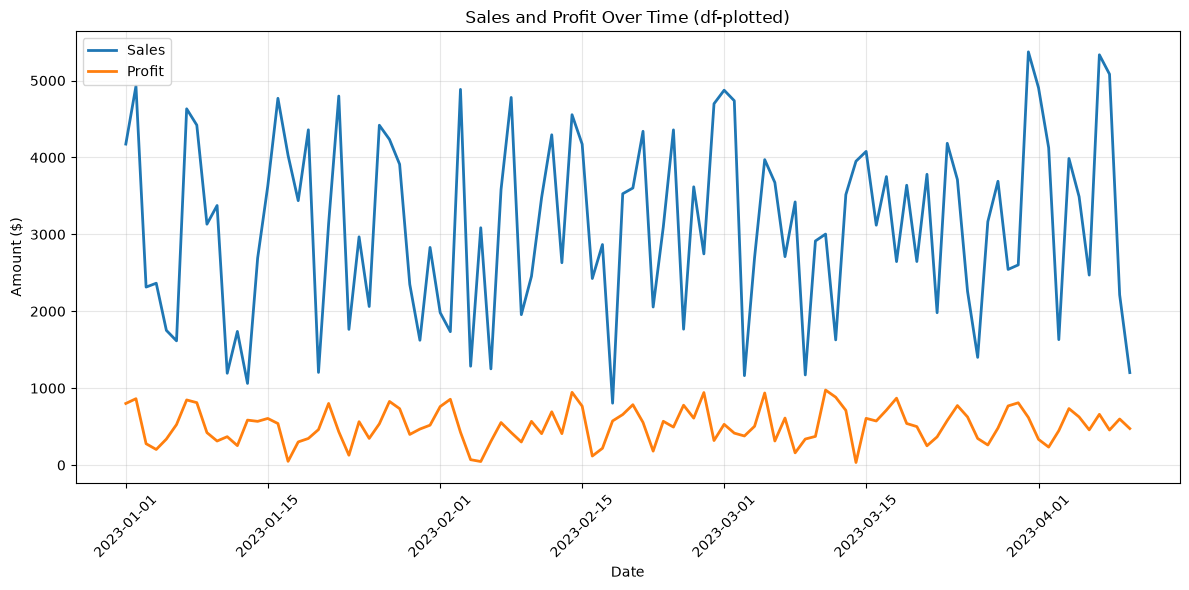

In [72]:
# Plot directly from DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Sales'], label='Sales', linewidth=2)
plt.plot(df['Date'], df['Profit'], label='Profit', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Amount ($)')
plt.title('Sales and Profit Over Time (df-plotted)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)  # Rotate x-axis labels
plt.tight_layout()
plt.show()

### Reading from .csv file

Instead of generating our own DataFrame using NumPy+Pandas, let's read in a premade CSV dataset.

In this case, our DataFrame is no longer named `df` and is named `iris`, so to plot it we will use `iris.plot()`.

Instead of using the default plot configurations, let's make it a scatter plot this time using the `kind='scatter'` argument. More specifically, let's make a scatter plot of the `sepal_length` and `sepal_width` columns.

> Note: A Matplotlib equivalent plot line is given in the comments.

     sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]


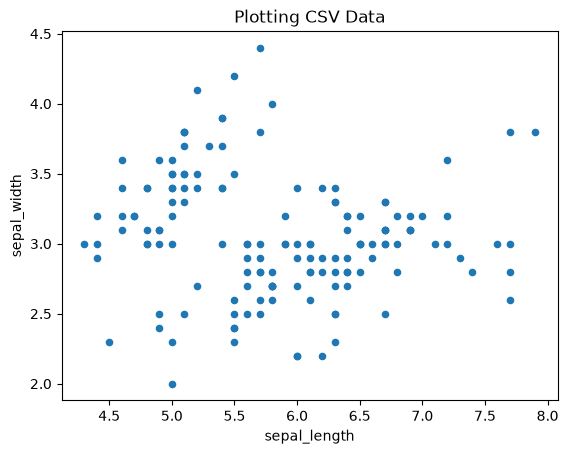

In [ ]:
# Reading data into a DataFrame (e.g., CSV file)
iris = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')
#print(iris)
# TODO: Uncomment the print statement above to show the tabulated data.

fig, ax = plt.subplots(nrows=1,ncols=1)
iris.plot(kind='scatter', x="sepal_length", y="sepal_width", ax=ax)

# Matplotlib equivalent
#ax.plot(iris['sepal_length'], iris['sepal_width'], 'o')

plt.title('Plotting CSV Data')
plt.show()

# Creates a new .csv file with the indexes included
df.to_csv("new_sample_dataset.csv", index=True)

## <a name="subplots"></a> Section 7: Subplots
Subplots allow you to create multiple plots in a single figure. This is great for comparing different visualizations, especially different representations of the same data.

In this first example, we want to display three trig graphs in a single column: sine, cosine, and tangent.
- Make sure you use the **Axes API** when declaring your subplots: `fig, ax = plt.subplots(3, 1)`
- Think of each subplot being an item in a list. In lists, we index each item; we do the same with subplots!
- Ex: the top left plot in a 2x2 grid is refereed to as `<ax_name>[0]`.

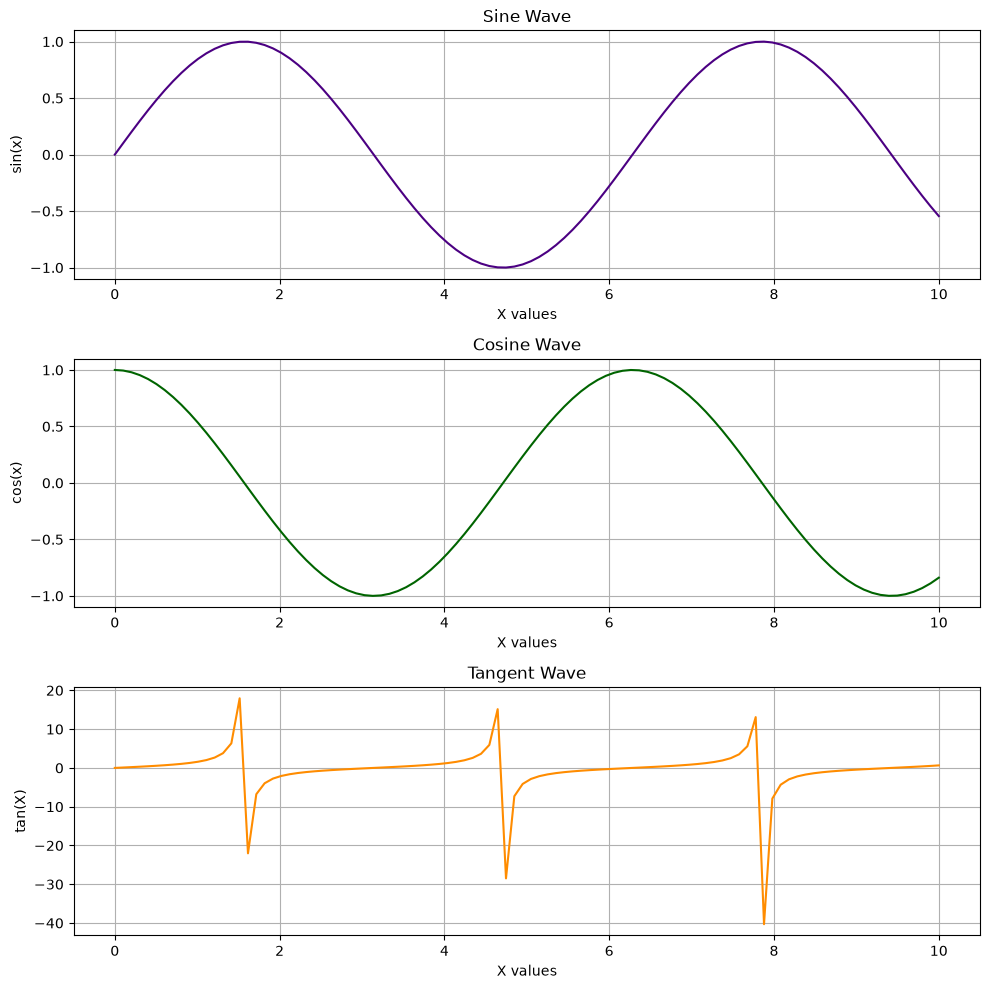

In [258]:
# Subplots of sin, cos, and tan
# Create some sample data
x = np.linspace(0, 10, 100)  # 100 points from 0 to 10

# Trig Subplots
# Sin Plot
fig, ax = plt.subplots(3, 1, figsize=(10, 10))
ax[0].plot(x, np.sin(x), color='indigo')
ax[0].set_xlabel('X values')
ax[0].set_ylabel('sin(x)')
ax[0].set_title('Sine Wave')
ax[0].grid(True)

# Cos Plot
ax[1].plot(x, np.cos(x), color='darkGreen')
ax[1].set_xlabel('X values')
ax[1].set_ylabel('cos(x)')
ax[1].set_title('Cosine Wave')
ax[1].grid(True)

# Tan Plot
ax[2].plot(x, np.tan(x), color='darkOrange')
ax[2].set_xlabel('X values')
ax[2].set_ylabel('tan(X)')
ax[2].set_title('Tangent Wave')
ax[2].grid(True)

plt.tight_layout()
plt.show()

Cool! We can show multiple graphs at once. Why stop there? We can display multiple plots at once, and they don't need to be the same type.

In this second example, display y=x^2, a scatterplot, a bar chart, and a pie chart.

**Fill in the missing pieces.**

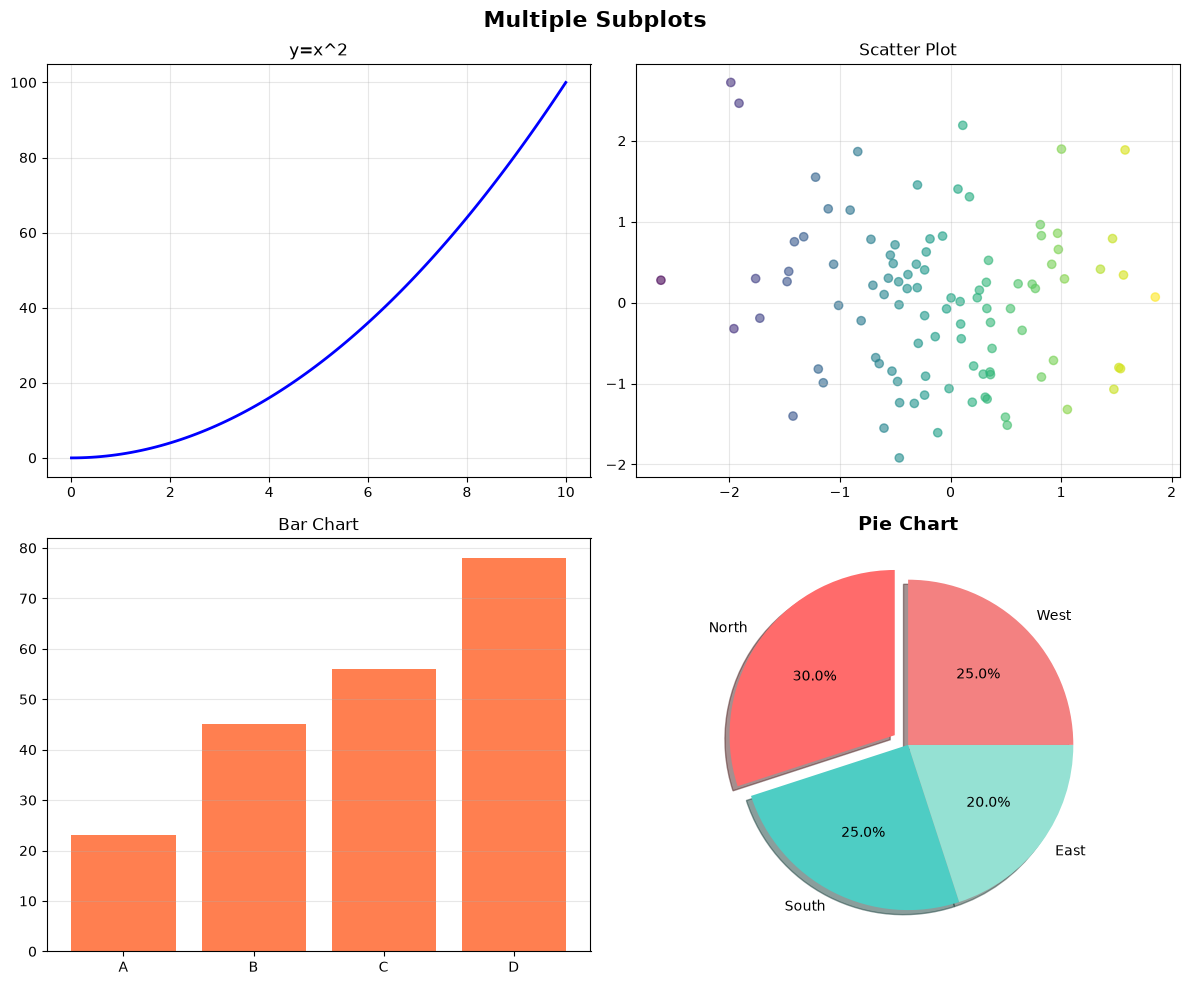

In [ ]:
# TODO: Add to slides & remove 2 lines to be filled in.
# Create 2x2 subplot grid
x = np.linspace(0, 10, 100)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Multiple Subplots', fontsize=16, fontweight='bold')

# Top left: Line plot
axes[0, 0].plot(x, x**2, 'b-', linewidth=2)
axes[0, 0].set_title('y=x^2')
axes[0, 0].grid(True, alpha=0.3)

# Top right: Scatter
np.random.seed(42)
x_scatter = np.random.randn(100)
y_scatter = np.random.randn(100)
axes[0, 1].scatter(x_scatter, y_scatter, alpha=0.6, c=x_scatter, cmap='viridis')
# TODO: Give this scatter plot a title.
axes[0, 1].grid(True, alpha=0.3)

# Bottom left: Bar Chart
categories = ['A', 'B', 'C', 'D']
values = [23, 45, 56, 78]
# TODO: Plot a bar chart on the bottom left that maps categories to values and is the color coral.
axes[1, 0].set_title('Bar Chart')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Bottom right: Pie Chart
categories = ['North', 'South', 'East', 'West']
sizes = [30, 25, 20, 25]
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181']
explode = (0.1, 0, 0, 0)  # Explode the first slice

axes[1,1].pie(sizes, explode=explode, labels=categories, colors=colors,
       autopct='%1.1f%%', shadow=True, startangle=90)
axes[1,1].set_title('Pie Chart', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Optional: Automating Name settings for all subplots
'''
plot_rows=2
plot_cols=2
for i in range(0,plot_rows):
    for j in range(0, plot_cols):
       axes[i,j].set_xlabel('X-data')
       axes[i,j].set_ylabel('Y-data')
       axes[i,j].legend()
       axes[i,j].set_title(f'Subplot {i+1}')
'''

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

## <a name="advanced-plots"></a> Section 8: Advanced Plots

### 2D Histograms
2D Histograms use the `hist2d()` function. They can be used to plot two data distributions against each other instead of individually, utilizing colormaps and colorbars to help visualize data.

* Here, we plot `dist2` versus `dist1` across 80 and 20 bins, respectively, assigning the plot to the variable `hist`.
* The `plt.colorbar()` function is used to create a colorbar for a given figure. Since we assigned our 2D histogram to the `hist` variable, this is what we pass to the colorbar function to create a colorbar distribution for the data.
* Note that in the case of 2D histograms, `hist[3]` specifically must be passed, but in general you can just pass the entire variable. Additionally, the colorbar function can accept multiple configuration arguments, like `location`, `orientation`, and a `label`.

* We've included an additional method in the comments below to implement a colorbar by manually creating axes for it. Using this method gives you tighter control over the height, width, ticks, and placement of your colorbar relative to a given figure.
* After creating an axis for a prospective colorbar with `fig.add_axes()`, you can then pass that axis to the `cax` argument in `plt.colorbar()` to actually use it.

More details about colorbar settings can be found here: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html

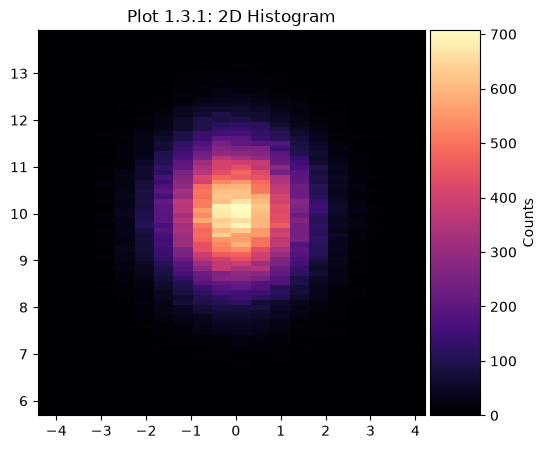

In [ ]:
# Histogram parameters & distribution data
N_points = 100000
dist1 = np.random.normal(size=N_points)
dist2 = np.random.normal(loc=10.0,size=N_points)

# Initialize the figure
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(5,5))

# Make 2D histogram
hist = ax.hist2d(dist1, dist2, bins=(20,80), cmap='magma')

# Method 1: Standard Colorbar Method
# hist[3] is used **in this case** because of how histograms display data
cbar=plt.colorbar(hist[3],location='right', orientation='vertical', label='Counts')

# Method 2: Customizeable Colorbar Method
# TODO: Comment out the standard colorbar above, and try this colorbar instead.
'''
cbaxes = fig.add_axes([.91, .11, .1, 0.77]) # Format: left edge position, bottom edge position, width, height
cbar=plt.colorbar(hist[3], orientation='vertical',cax=cbaxes)
cbaxes.yaxis.set_ticks_position('right') # must come AFTER plt.colorbar call
cbar.set_label('Counts',rotation=90,size=10, loc='center') # x=, y= can also be called here to set location of label (y for vertical cbars, x for horizontal cbars)
'''

ax.set_title('Plot 1.3.1: 2D Histogram')

# "Show" the plot
plt.show()

### 3D Plots

Plotting 3D data in Matplotlib isn't very common since other tools provide more specialized handling of 3D data. However, you can still visualize simple 3D datasets with Matplotlib.

* In this example, we will generate random points in the form of a cube, but plot a specific selection of them. We will only care about the ones within a radius of 1 relative to the center of the domain.

**The key to getting a 3D plot to work in Matplotlib is to use the `subplot_kw={'projection': '3d'}` keyword argument in `plt.subplots()`.**
1) Here, we generate 1000 random `x`, `y`, and `z` datapoints confined to a domain of [-1,1) using the `np.random.rand()` function.
2) Next, we calculate the radius (`r`) from each point to the center, and slice the data so that we only include points with `r<=1`.
3) Next, we use the `scatter()` function to make a scatter plot of all of our points within r=1. Alternatively, you can use the `plot()` function with certain markers and line styles.

*An aside:* This example is a convenient introduction into Monte Carlo methods. Using our initial random distribution of samples (which form a cube-like object), we can try and estimate the volume of a sphere just by knowing
1. the number of datapoints lying in the "sphere" (i.e., points where r=1)
and
2. the total number of points.

The more you increase the sample size, the accurate the estimate should be (theoretically).
* The ratio of volumes = # of points within the sphere / total # of points in the box.
* Thus, ratio between points * volume of the "cube" $\approx$ volume of the sphere.

For more examples of 3D plots in Matplotlib, see: https://matplotlib.org/stable/gallery/mplot3d/index.html

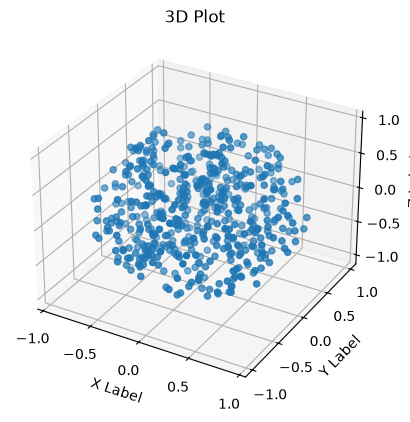

Real volume of a sphere of r=1 is 4.1887902047863905
Approximate volume is 4.136


In [33]:
# Fixing random state for reproducibility
np.random.seed(19680800)

# Create random data from [-1,1), Math: [0,1) --> [0,2) --> [-1,1)
x = ( 2. * np.random.rand(1000) ) - 1.
y = ( 2. * np.random.rand(1000) ) - 1.
z = ( 2. * np.random.rand(1000) ) - 1.

# Extract points within a r=1 sphere
r = np.sqrt(x**2 + y**2 + z**2)
x_sphere = x[ r<=1 ]
y_sphere = y[ r<=1 ]
z_sphere = z[ r<=1 ]

# Initialize the 3D figure
fig, ax = plt.subplots(subplot_kw={'projection': '3d'})

# Make a scatter plot with either the "scatter" method or just plotting with "plot" without a linestyle
ax.scatter(x_sphere,y_sphere,z_sphere, marker='o')
#ax.plot(x_sphere,y_sphere,z_sphere, marker='.', ls='', alpha=0.5)

# Annotations --> This is how we label the axes in this case; we'll dive into this soon.
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
ax.set_title('3D Plot')

# "Show" the plot
plt.show()

# Just for fun, this is a good example of a very intro Monte Carlo problem
N_box = 1000. # total number of random points within [-1,1]
N_sphere = len(r[r<=1.]) # number of points within the sphere
vol_box = 2.**3.
vol_sphere = vol_box*(N_sphere/N_box)

print('Real volume of a sphere of r=1 is', (4./3.)*np.pi)
print('Approximate volume is', vol_sphere)

## <a name="advanced-custom"></a> Section 9: Advanced Customization

Matplotlib offers much more styling options than we have discussed so far. You can add annotations to your plots and have finer control over legends (e.g., location, font, title, other styling).

Annotations are additional labels that can inserted on top of the plot. An annotation is created by `ax.annotate, and the options include the following:
* text: The literal string that appears with the annotation
* xy: Coordinates for the annotation
* arrowprops: Styling options for arrows connecting to the annotation
* fontsize
* fontweight
* color

Text boxes are another form of labels that are inserted on top of the plot and can placed with using absolute psoitioning.

Customizing the legend is also possible through Matplotlib. You can adjust where the legend will appear, border styling, shadowing, font size, and a legend title label.

C:\Users\loved\AppData\Local\Temp\ipykernel_20744\1595912570.py:9: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  ax.plot(x, y2, 'b-', linewidth=2, label='sqrt(x)', color='green')


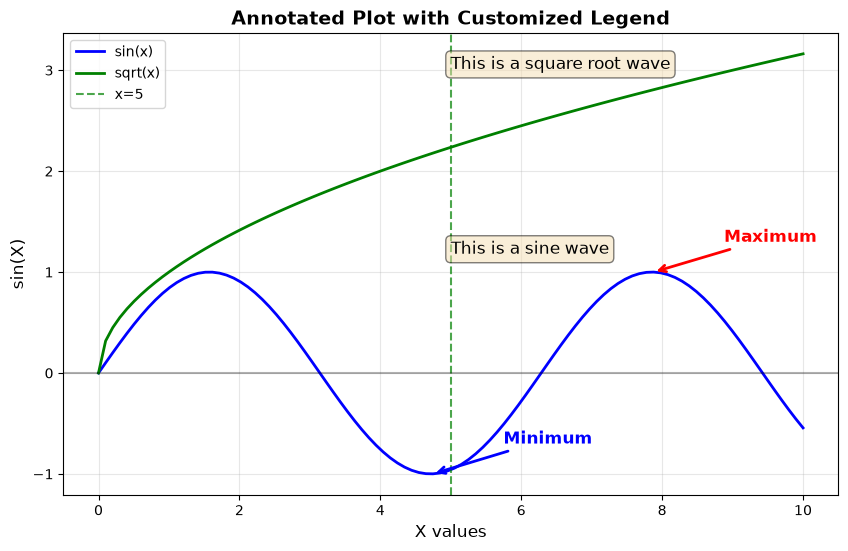

In [ ]:
# Adding annotations and text
x = np.linspace(0, 10, 100)
y = np.sin(x)
y2 = x**0.5

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'b-', linewidth=2, label='sin(x)')
ax.plot(x, y2, 'b-', linewidth=2, label='sqrt(x)', color='green')

# Add text annotation
max_idx = np.argmax(y)
min_idx = np.argmin(y)
ax.annotate('Maximum', xy=(x[max_idx], y[max_idx]), 
            xytext=(x[max_idx] + 1, y[max_idx] + 0.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, color='red', fontweight='bold')
ax.annotate('Minimum', xy=(x[min_idx], y[min_idx]), 
            xytext=(x[min_idx] + 1, y[min_idx] + 0.3),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2),
            fontsize=12, color='blue', fontweight='bold')

# Add text boxes
ax.text(0.5, 0.95, 'This is a square root wave', 
        transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.5))

ax.text(0.5, 0.55, 'This is a sine wave', 
        transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.5))

# Add vertical and horizontal lines
ax.axvline(x=5, color='green', linestyle='--', alpha=0.7, label='x=5')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Customize legend
ax.legend(loc='upper right', frameon=True, fancybox=True, 
          shadow=True, fontsize=10, title='Functions')

ax.set_xlabel('X values', fontsize=12)
ax.set_ylabel('sin(X)', fontsize=12)
ax.set_title('Annotated Plot with Customized Legend', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.show()

## <a name="save"></a> Section 10: Saving Figures
You can export your plots for reports, presentations, and just generally sharing your work!

We'll show you how to do this using the 2D histogram from above.

**Common Exporting Formats:**
- PNG
- PDF
- SVG
- EPS

**Common save parameters:**
- `dpi`: Resolution (dots per inch). Higher = better quality but larger file
- `bbox_inches='tight'`: Removes extra whitespace
- `format`: Explicit format specification
- `facecolor`: Background color

Figure saved as 'magma_2d_histogram.png' and 'magma_2d_histogram.pdf'


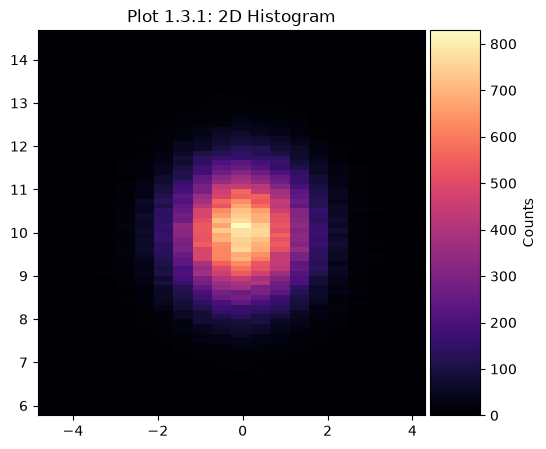

In [261]:
# Using the 2D histogram example from above
# Histogram parameters & distribution data
N_points = 100000
dist1 = np.random.normal(size=N_points)
dist2 = np.random.normal(loc=10.0,size=N_points)

# Initialize figure
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(5,5))

# Make 2D histogram
hist = ax.hist2d(dist1, dist2, bins=(20,80), cmap='magma')

# Colorbar
cbaxes = fig.add_axes([.91, .11, .1, 0.77]) # Format: left edge position, bottom edge position, width, height
cbar=plt.colorbar(hist[3], orientation='vertical',cax=cbaxes)
cbaxes.yaxis.set_ticks_position('right') # must come AFTER plt.colorbar call
cbar.set_label('Counts',rotation=90,size=10, loc='center') # x=, y= can also be called here to set location of label (y for vertical cbars, x for horizontal cbars)

ax.set_title('Plot 1.3.1: 2D Histogram')

# Save the figure
# Common formats: PNG (raster), PDF (vector), SVG (vector), EPS (vector)
fig.savefig('magma_2d_histogram.png', dpi=300, bbox_inches='tight')
fig.savefig('magma_2d_histogram.pdf', bbox_inches='tight')  # Vector format (scalable)
print("Figure saved as 'magma_2d_histogram.png' and 'magma_2d_histogram.pdf'")

plt.show()

## <a name="cheat-sheet"></a> Common Matplotlib Functions Cheat Sheet

Quick reference for frequently used Matplotlib functions and parameters.


### Plot Types
- `plt.plot()` - Line plot
- `plt.scatter()` - Scatter plot
- `plt.bar()` / `plt.barh()` - Bar chart (vertical/horizontal)
- `plt.hist()` - Histogram
- `plt.boxplot()` - Box plot
- `plt.pie()` - Pie chart
- `plt.imshow()` - Display image/2D array

### Figure and Axes Creation
- `plt.figure(figsize=(width, height))` - Create figure
- `plt.subplots(nrows, ncols)` - Create subplots
- `fig, ax = plt.subplots()` - Object-oriented approach
- `plt.subplot2grid()` - Uneven subplot layouts

### Customization
- `plt.xlabel()` / `ax.set_xlabel()` - X-axis label
- `plt.ylabel()` / `ax.set_ylabel()` - Y-axis label
- `plt.title()` / `ax.set_title()` - Plot title
- `plt.legend()` / `ax.legend()` - Show legend
- `plt.grid()` / `ax.grid()` - Add grid
- `plt.xlim()` / `ax.set_xlim()` - Set x-axis limits
- `plt.ylim()` / `ax.set_ylim()` - Set y-axis limits
- `plt.xticks()` / `ax.set_xticks()` - Customize x-axis ticks
- `plt.yticks()` / `ax.set_yticks()` - Customize y-axis ticks

### Colors and Styles
- Colors: `'b'`, `'r'`, `'g'`, `'c'`, `'m'`, `'y'`, `'k'`, `'w'`
- Color names: `'steelblue'`, `'coral'`, `'darkgreen'`, etc.
- Hex codes: `'#FF6B6B'`
- Line styles: `'-'` (solid), `'--'` (dashed), `'-.'` (dash-dot), `':'` (dotted)
- Markers: `'o'`, `'s'`, `'^'`, `'*'`, `'+'`, `'x'`, `'D'`

### Annotations and Text
- `plt.annotate()` / `ax.annotate()` - Add annotation with arrow
- `plt.text()` / `ax.text()` - Add text
- `plt.axvline()` / `ax.axvline()` - Vertical line
- `plt.axhline()` / `ax.axhline()` - Horizontal line

### Saving and Displaying
- `plt.savefig(filename, dpi=300, bbox_inches='tight')` - Save figure
- `plt.show()` - Display plot
- `plt.tight_layout()` - Adjust spacing between subplots
- `plt.close()` - Close figure to free memory

### Working with Pandas
- `df.plot()` - Plot directly from DataFrame
- `df.plot(kind='line')` - Specify plot type
- `df.plot(x='col1', y='col2')` - Specify columns
- `df.head()` - First 5 rows of df
- `df.tail()` - Last 5 rows of df

### Styles
- `plt.style.use('style_name')` - Apply style
- Common styles: `'default'`, `'seaborn'`, `'ggplot'`, `'dark_background'`
- `plt.style.available` - List all available styles

# <a name="optional"></a> Extra Content
Eager to learn more? There are some sections of additional content and the fundamentals of Seaborn below.

## <a name="seaborn"></a> Seaborn
Let's load the built-in "car crashes" and "tips" datasets 

In [263]:
import seaborn as sns
%matplotlib inline

# Built-in datasets
crash_df = sns.load_dataset('car_crashes')
tips_df = sns.load_dataset('tips')
flights = sns.load_dataset("flights")

### Distribution Plots

* Provides a way to look at a univariate distribution, which focuses on a single variable. 
* Kernal Density Estimation approximates the distribution (or density) of the data within a histogram.
    * `kde=False` removes the KDE
* Bins define how many buckets to divide the data up into between intervals

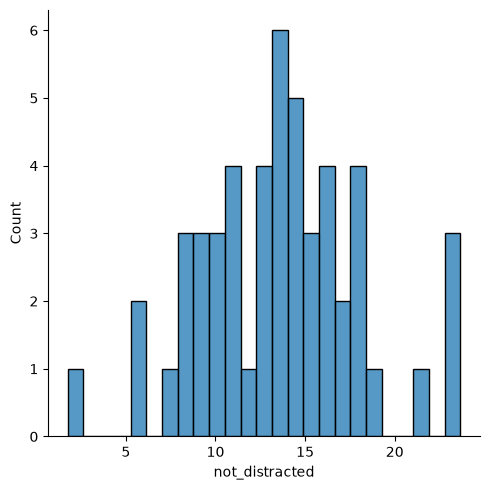

In [264]:
sns.displot(crash_df['not_distracted'], kde=False, bins=25)

### Joint & KDE Plots

* Jointplot compares 2 distributions and plots a scatter plot by default

`kind` parameter:
- `reg` = Regression Line
- `kde` = KDE Plot
- `hex` = Hexagonal Distribution

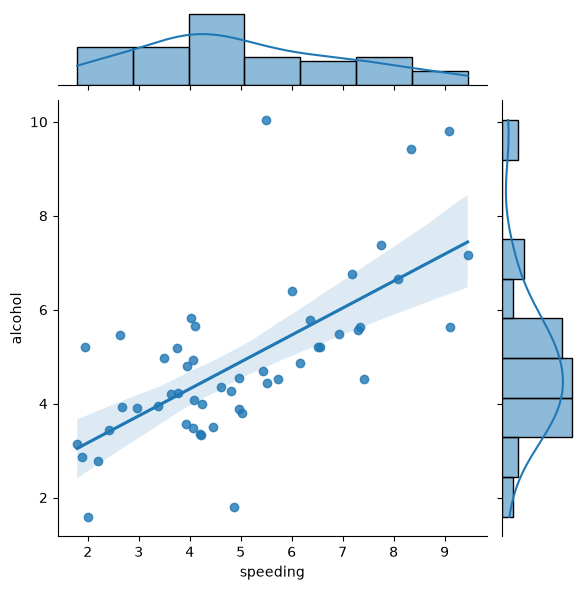

In [267]:
# As we can see as people tend to speed they also tend to drink & drive
# Through the kind parameter, you can different distributions

# This joint plot displays a scatterplot with a regression line as well as the kde plots for both sets of variable values
sns.jointplot(x='speeding', y='alcohol', data=crash_df, kind='reg')

### Pair Plots
Pair Plot plots relationships across the entire data frames numerical values.

They can be particularly useful for observing patterns between categorical data and the any type of dispersion throughout the data.

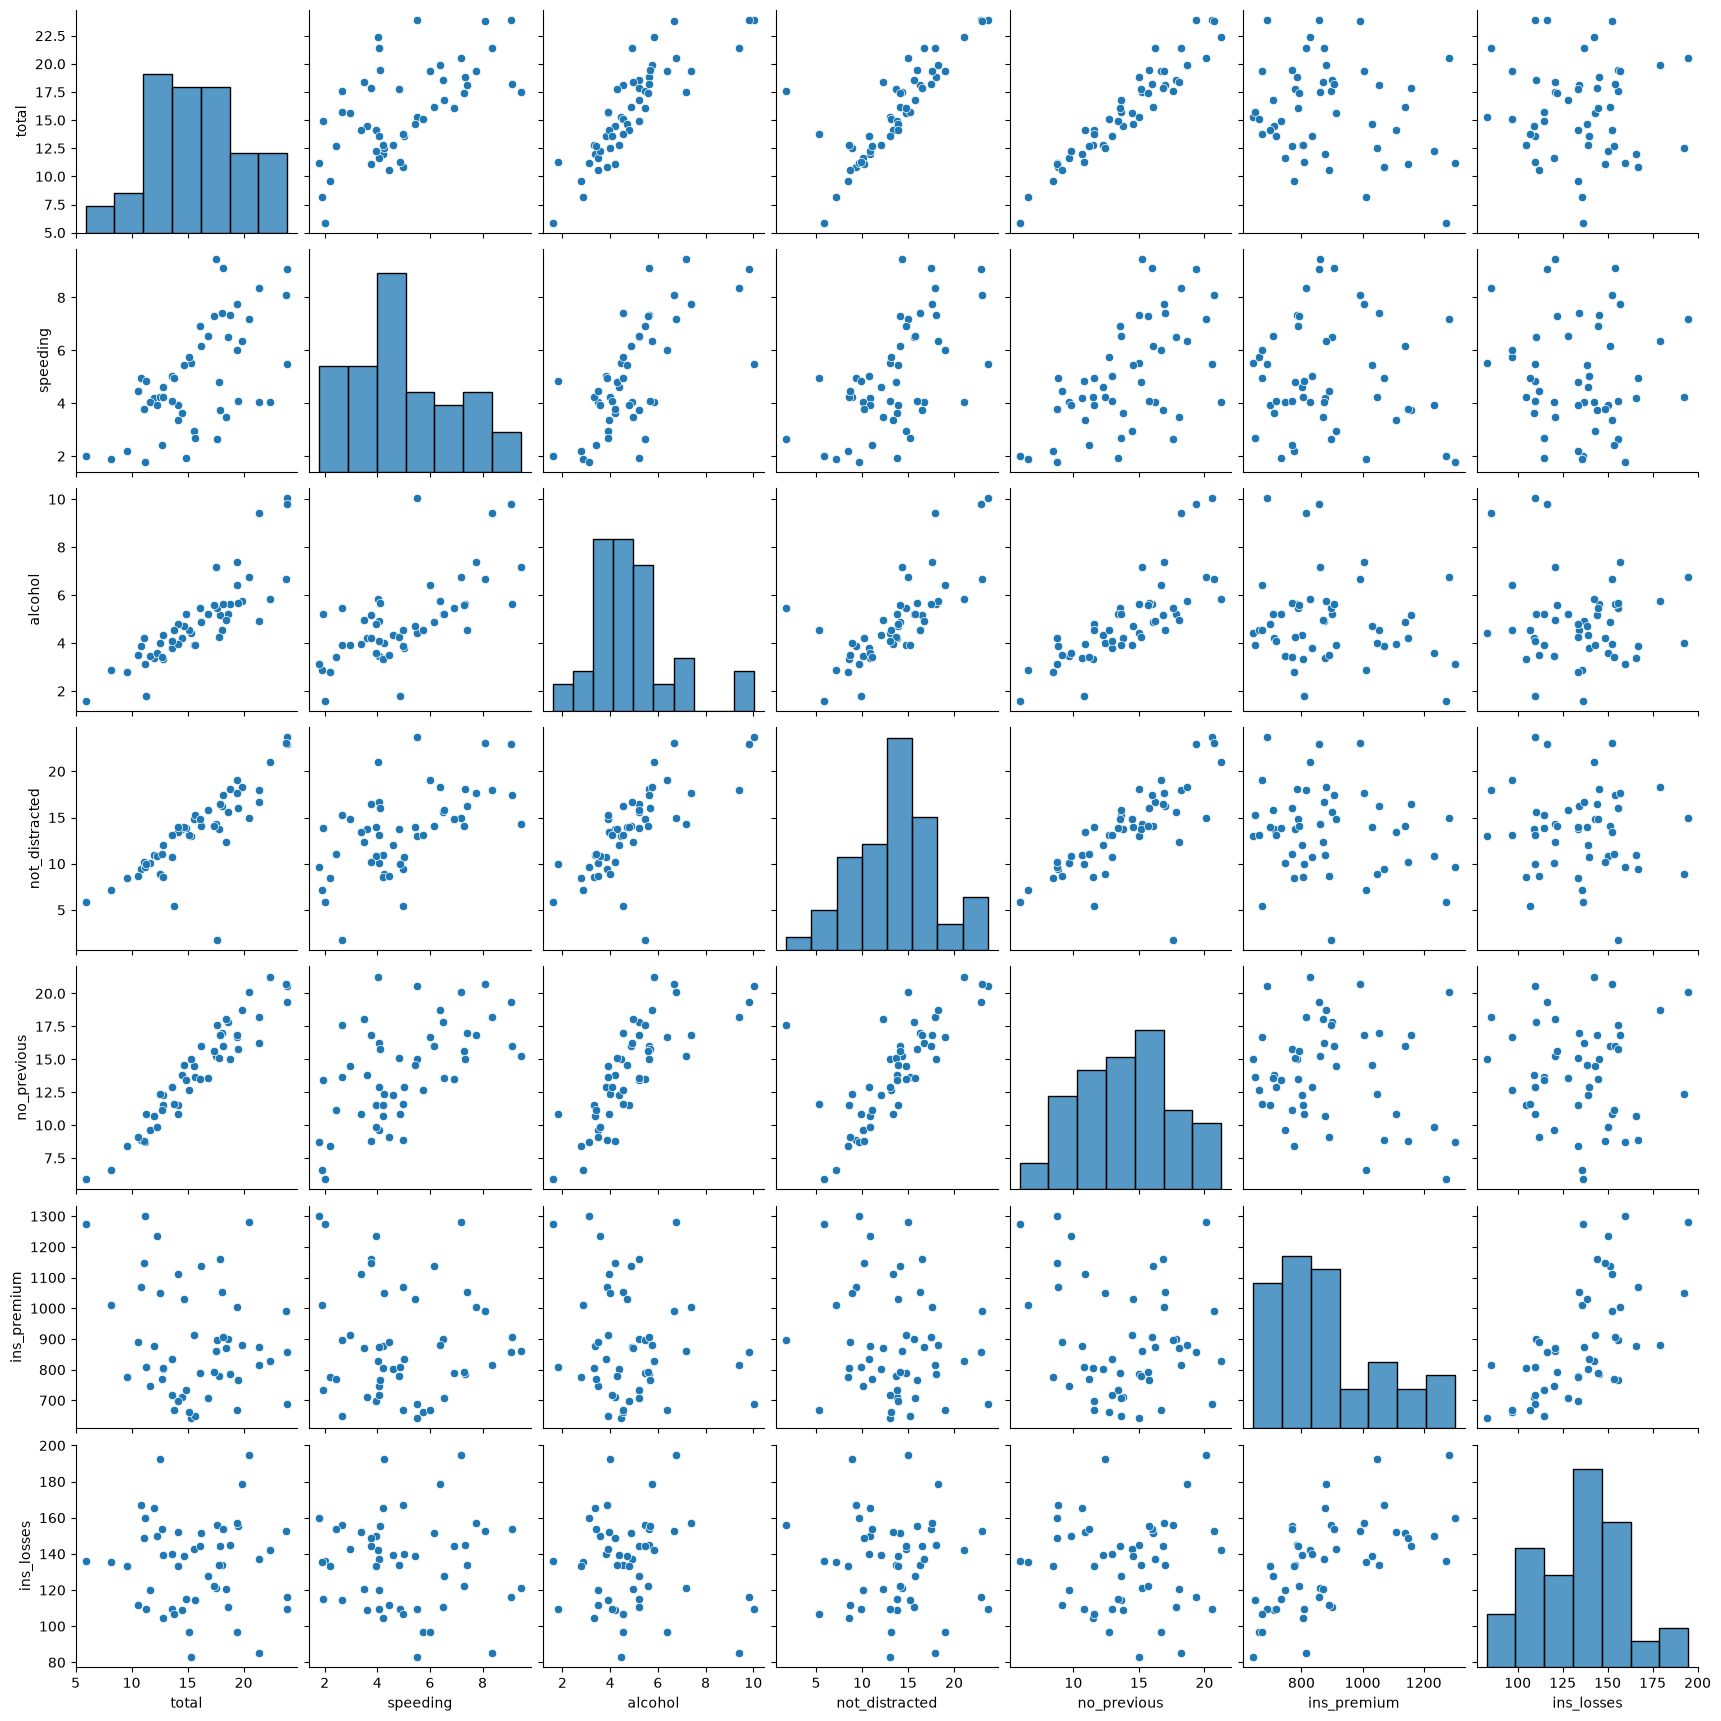

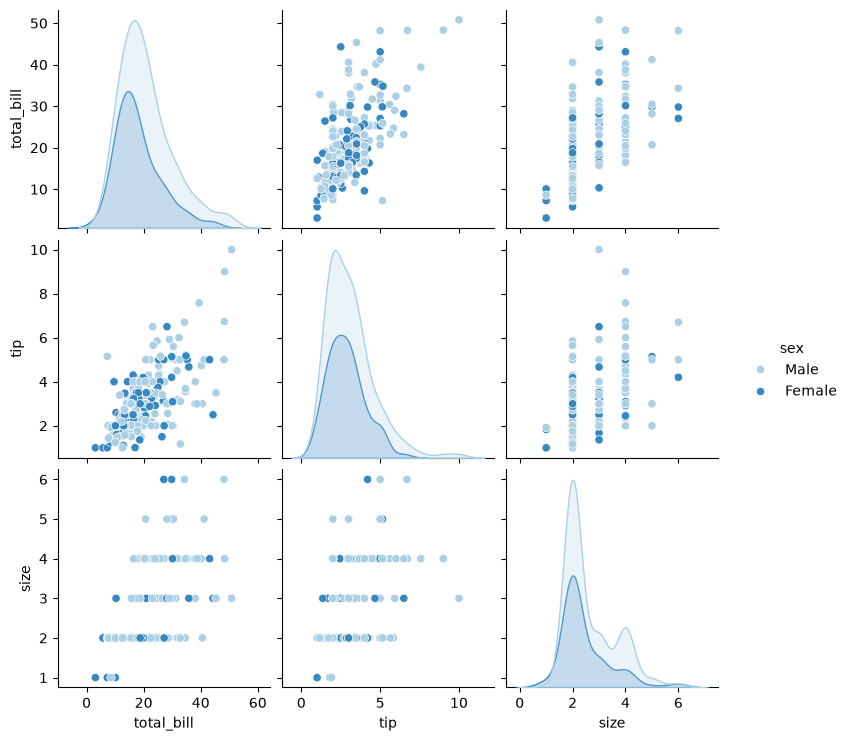

In [151]:
sns.pairplot(crash_df)

# You can use color maps from Matplotlib to define what colors to use
sns.pairplot(tips_df, hue='sex', palette='Blues')

### Aesthetics & Styling

`set_style`: Sets a white or dark background with grid options

`set_context`: Three options for size and specific font scales
- Paper = Smallest
- Talk = Medium-sized; good for presentations
- Poster = Large; suitable for posters

`despine`: Removes the axis spines when enabled

<Figure size 800x400 with 0 Axes>

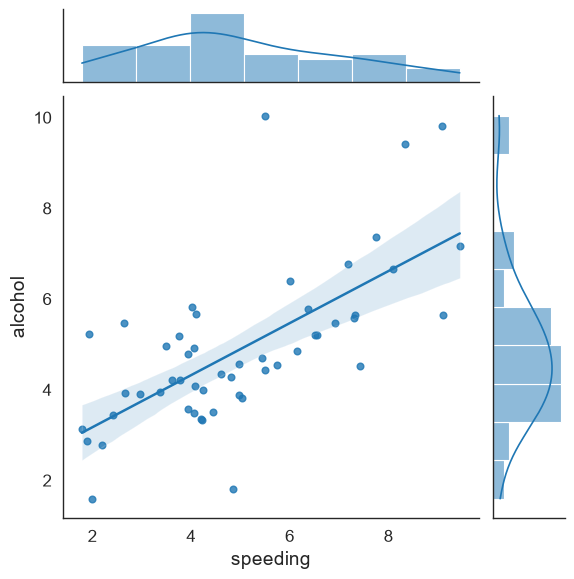

In [271]:
# You can set styling for your axes and grids
# white, darkgrid, whitegrid, dark, ticks
# TODO: Try different options for set_styles and set_context
sns.set_style('white')

# You can use figure sizing from Matplotlib
plt.figure(figsize=(8,4))

# Change size of labels, lines and other elements to best fit
# how you will present your data (paper, talk, poster)
sns.set_context('paper', font_scale=1.4)

sns.jointplot(x='speeding', y='alcohol', data=crash_df, kind='reg')

# Get rid of spines
# You can turn of specific spines with right=True, left=True, bottom=True, top=True
sns.despine(left=False, bottom=False)

**Palettes**

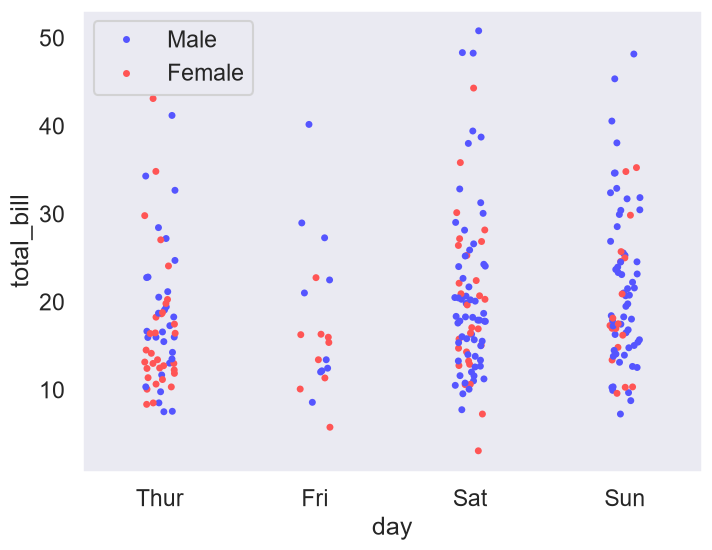

In [ ]:
plt.figure(figsize=(8,6))

sns.set_style('dark')
sns.set_context('talk')

# You can use Matplotlibs color maps for color styling: https://matplotlib.org/3.3.1/tutorials/colors/colormaps.html
sns.stripplot(x='day',y='total_bill',data=tips_df, hue='sex', palette='seismic')

# Add the optional legend with a location number (best: 0, upper right: 1, upper left: 2, lower left: 3, lower right: 4, https://matplotlib.org/3.3.1/api/_as_gen/matplotlib.pyplot.legend.html) or supply a tuple of x & y from lower left
plt.legend(loc=0)

### Facet Grids

The `FacetGrid()` plot is another useful Seaborn method.

Essentially, it's able to plot conditional relationships between different data in a given DataFrame. Typically it's used to create a handful of subplots that relate to each other.

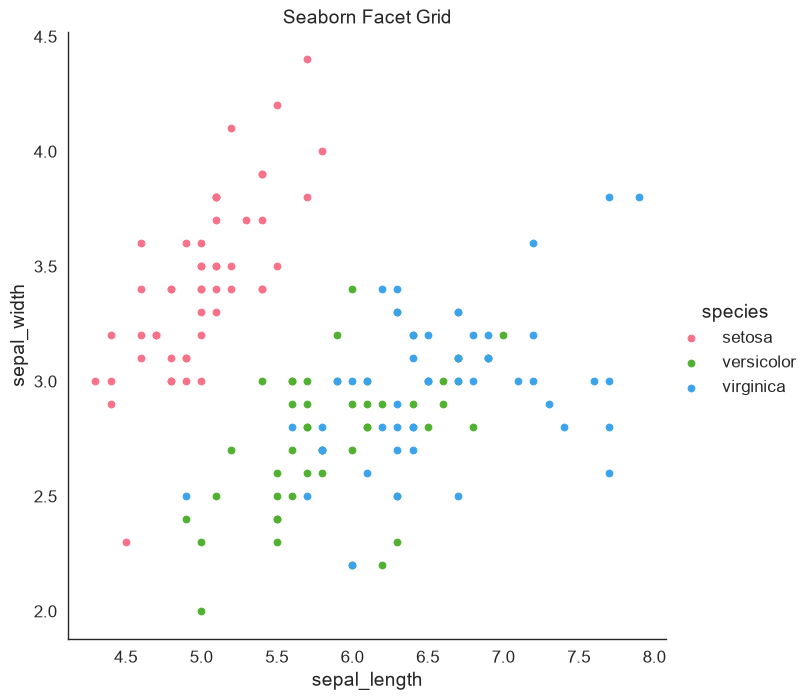

In [193]:
# Read in DataFrame
iris = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')

# FacetGrid Plot
# Color depends on the species in the dataset (often a categorical variable)
sns.FacetGrid(iris, hue="species", palette="husl", height=7) \
   .map(plt.scatter, "sepal_length", "sepal_width") \
   .add_legend()

# Title
plt.title('Seaborn Facet Grid')

# "Show" the plot
plt.show()

### Regression Plots

In [152]:
# lmplot combines regression plots with facet grid
tips_df = sns.load_dataset('tips')
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


We can plot a regression plot studying whether total bill effects the tip.

`hue` is used to show separation based off of categorical data. We see that males tend to tip slightly more.

<Figure size 600x400 with 0 Axes>

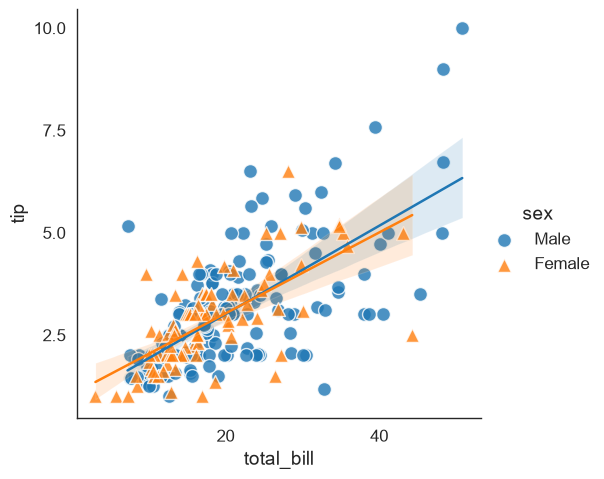

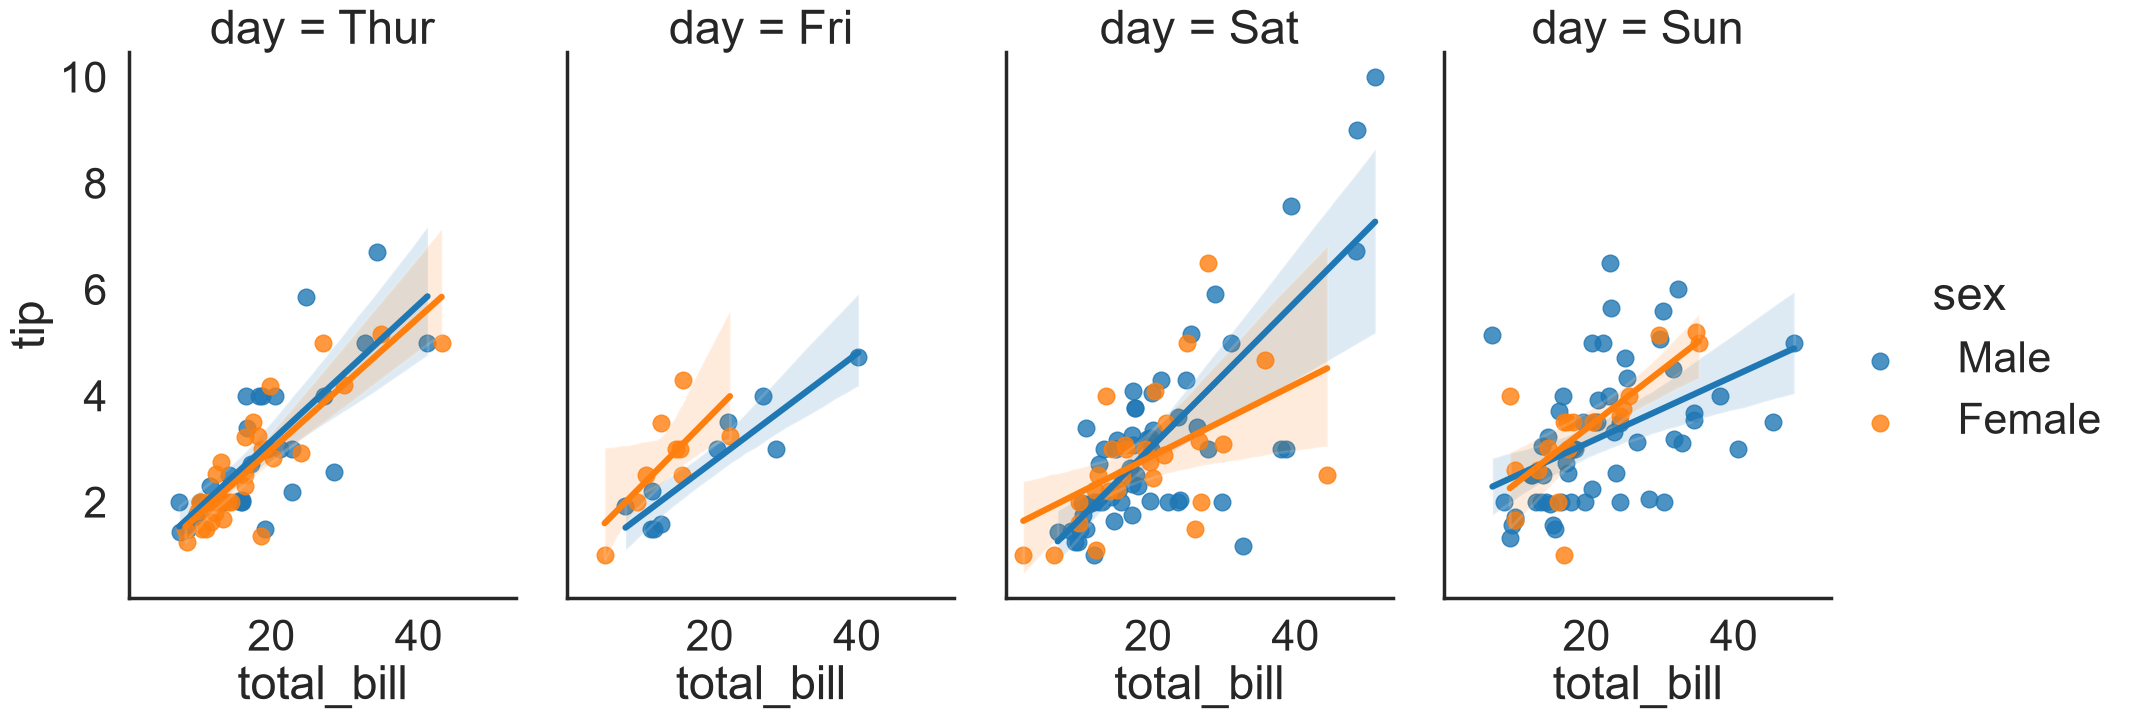

In [200]:
plt.figure(figsize=(6,4))
sns.set_context('paper', font_scale=1.4)

# We can plot a regression plot studying whether total bill effects the tip
# hue is used to show separation based off of categorical data
# We see that males tend to tip slightly more

# Let's define different markers for men and women
sns.lmplot(x='total_bill', y='tip', hue='sex', data=tips_df, markers=['o', '^'], 
          scatter_kws={'s': 100, 'edgecolor': 'w'})


# You can separate the data into separate columns for day data

# Makes the fonts more readable
sns.set_context('poster', font_scale=1.4)
sns.lmplot(x='total_bill', y='tip', data=tips_df, col='day', hue='sex',
          height=8, aspect=0.6)


### Heatmaps

Correlation tells you how influential a variable is on the result. Heatmaps are excellent in effectively displaying correlational patterns through the use of colors.

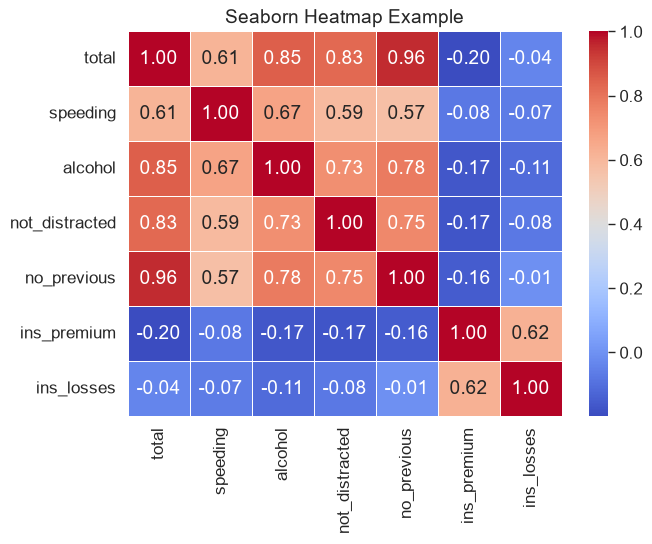

In [ ]:
# Car Crashes Heatmap Example

# Generating correlation data from the car_crashes dataset
crash_mx = crash_df.corr(numeric_only=True)

# Generate heatmap with built-in annotations and styling
plt.figure(figsize=(7, 5))
sns.set_context('paper', font_scale=1.4)
sns.heatmap(
    crash_mx,
    annot=True,  # Write the numeric values inside cells
    fmt=".2f",  # Round values to two decimal spots
    cmap="coolwarm",  # Pick a diverging color scheme
    linewidths=0.5,  # Add subtle margins between grid boxes
)
# Notice that n previous accident is heavily correlated with accidents, while the insurance premium is not

plt.title("Seaborn Heatmap Example")
plt.show()

<Axes: xlabel='year', ylabel='month'>

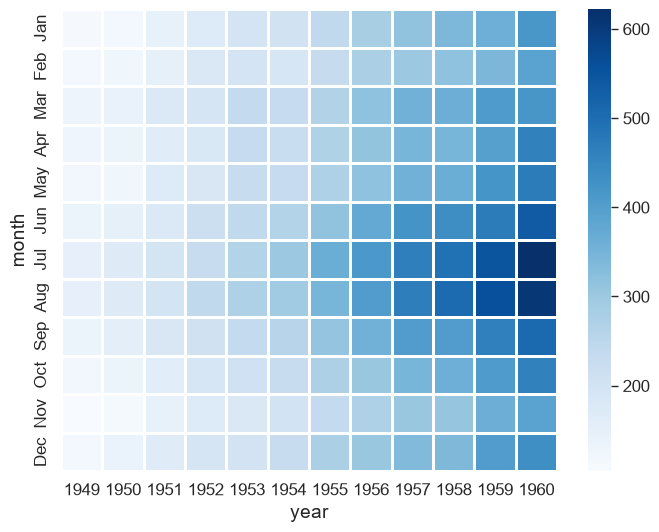

In [224]:
# Flights Heatmap Example

plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)

# We can create a matrix with an index of month, columns representing years and the number of passengers for each
# We see that flights have increased over time and that most people travel in July and August
flights = flights.pivot_table(index='month', columns='year', values='passengers')

# You can separate data with lines
sns.heatmap(flights, cmap='Blues', linecolor='white', linewidth=1)

## <a name="cool-plots"></a> More Fun Features

These are just some cool plots that are possible with Matplotlib and Seaborn. Some are them are not common or practical but are pretty neat nevertheless.

### Violin Plots

<Axes: xlabel='day', ylabel='total_bill'>

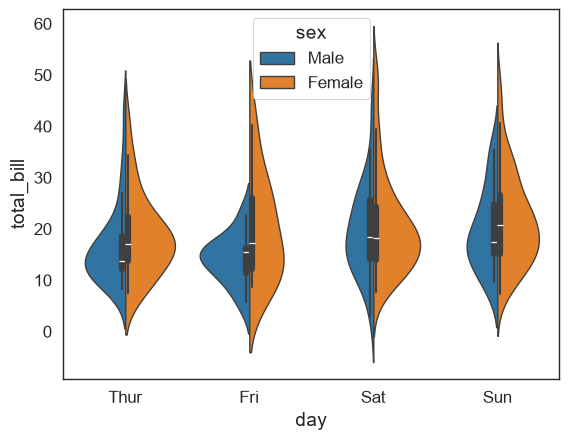

In [182]:
# A violin plot is a combination of the boxplot and KDE
# While a box plot corresponds to data points, the violin plot uses the KDE estimation

# Split allows you to compare how the categories compare to each other
sns.violinplot(x='day',y='total_bill',data=tips_df, hue='sex',split=True)

C:\Users\loved\AppData\Local\Temp\ipykernel_20744\2154476286.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='day',y='total_bill',data=tips_df, palette='seismic')


<Axes: xlabel='day', ylabel='total_bill'>

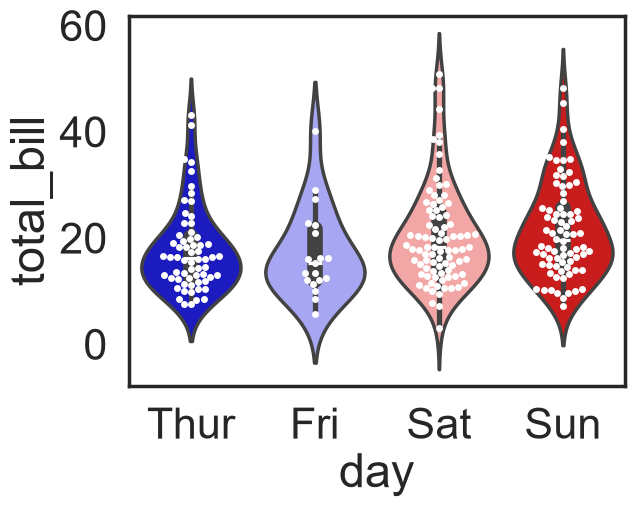

In [ ]:
# You can stack a violin plot with a swarm plot
# Comment out the violin plot and see what the swarm plot looks like alone

sns.violinplot(x='day',y='total_bill',data=tips_df, palette='seismic')
sns.swarmplot(x='day',y='total_bill',data=tips_df, color='white')

### Contour Images

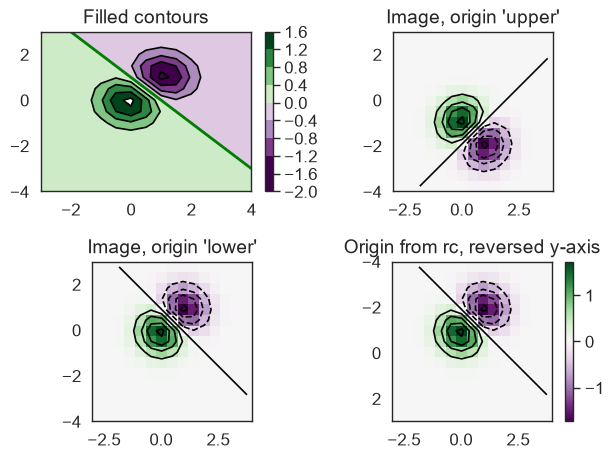

In [226]:
from matplotlib import cm

# Default delta is large because that makes it fast illustrates the correct registration between image and contours.
delta = 0.5
extent = (-3, 4, -4, 3)

x = np.arange(-3.0, 4.001, delta)
y = np.arange(-4.0, 3.001, delta)
X, Y = np.meshgrid(x, y)
Z1 = np.exp(-X**2 - Y**2)
Z2 = np.exp(-(X - 1)**2 - (Y - 1)**2)
Z = (Z1 - Z2) * 2

# Boost the upper limit to avoid truncation errors.
levels = np.arange(-2.0, 1.601, 0.4)

norm = cm.colors.Normalize(vmax=abs(Z).max(), vmin=-abs(Z).max())
cmap = plt.colormaps["PRGn"]

fig, _axs = plt.subplots(nrows=2, ncols=2)
fig.subplots_adjust(hspace=0.3)
axs = _axs.flatten()

cset1 = axs[0].contourf(X, Y, Z, levels, norm=norm,
                        cmap=cmap.resampled(len(levels) - 1))
# It is not necessary, but for the colormap, we need only the number of levels minus 1.
# To avoid discretization error, use either this number or a large number such as the default (256).

# If we want lines as well as filled regions, we need to call  contour separately; don't try to change the edgecolor or edgewidth of the polygons in the collections returned by contourf.
# Use levels output from previous call to guarantee they are the same.

cset2 = axs[0].contour(X, Y, Z, cset1.levels, colors='k')
cset2.set_linestyle('solid')

# It is easier here to make a separate call to contour than to set up an array of colors and linewidths.
# We are making a thick green line as a zero contour. Specify the zero level as a tuple with only 0 in it.

cset3 = axs[0].contour(X, Y, Z, (0,), colors='g', linewidths=2)
axs[0].set_title('Filled contours')
fig.colorbar(cset1, ax=axs[0])


axs[1].imshow(Z, extent=extent, cmap=cmap, norm=norm)
axs[1].contour(Z, levels, colors='k', origin='upper', extent=extent)
axs[1].set_title("Image, origin 'upper'")

axs[2].imshow(Z, origin='lower', extent=extent, cmap=cmap, norm=norm)
axs[2].contour(Z, levels, colors='k', origin='lower', extent=extent)
axs[2].set_title("Image, origin 'lower'")

# We will use the interpolation "nearest" here to show the actual image pixels.
# Note that the contour lines don't extend to the edge of the box. This is intentional.
# The Z values are defined at the center of each image pixel.
im = axs[3].imshow(Z, interpolation='nearest', extent=extent,
                   cmap=cmap, norm=norm)
axs[3].contour(Z, levels, colors='k', origin='image', extent=extent)
ylim = axs[3].get_ylim()
axs[3].set_ylim(ylim[::-1])
axs[3].set_title("Origin from rc, reversed y-axis")
fig.colorbar(im, ax=axs[3])

fig.tight_layout()
plt.show()

## <a name="more-packages"></a> Additional Packages to Explore

* Python Packages
    * [Scipy](https://docs.scipy.org/doc/scipy/) (The "math/science" compliment to NumPy, which is geared toward integration, interpolation, etc.)
    * [Geopandas](https://geopandas.org/en/stable/docs.html) (Good tool for dealing with geographic/location data)
    * [Plotly](https://plotly.com/python/) (Good tool to look into for sharing interactive plots)
    * [yt](https://yt-project.org/doc/) (Common astro plotting/data processing tool but works with other domains too)
 
* Bigger Visualization Tools (typically used to visualize and model 3D data):
    * [Visit](https://visit-dav.github.io/visit-website/)
    * [ParaView](https://www.paraview.org/)